# 05 — DOMINANT vs GAD-NR: Grafo de Miembros (M)

Este notebook entrena y compara dos detectores de anomalías sobre el grafo de miembros `M`
usando la librería **PyGOD 1.1.0**:

- **DOMINANT** (Ding et al., SDM 2019): línea base consolidada en la literatura — encoder GCN
  compartido con dos decoders que reconstruyen estructura y atributos por separado.
- **GAD-NR** (Roy et al., WSDM 2024): estado del arte en la familia GNN+AE — reconstruye el
  vecindario completo de cada nodo (features propias, grado y distribución de atributos de vecinos).

## ¿Por qué este par de modelos?

Ambos pertenecen a la misma familia arquitectónica (GNN + Autoencoder, no supervisado) y
operan sobre el mismo objeto `Data` de PyG, lo que hace la comparativa limpia y directa.
La diferencia fundamental está en **qué reconstruyen**:

| Modelo | Reconstruye | Detecta bien |
|--------|------------|---------------|
| DOMINANT | Adyacencia $\hat{A}$ + features $\hat{X}$ | Anomalías estructurales y de atributos por separado |
| GAD-NR | Vecindario completo (features, grado, distribución de vecinos) | Anomalías contextuales, estructurales y joint-type |

## Esquema del notebook

| Sección | Contenido |
|---------|-----------|
| 0 | Imports y configuración |
| 1 | Carga del grafo M |
| 2 | Fundamento teórico: DOMINANT y GAD-NR |
| 3 | Entrenamiento de DOMINANT |
| 4 | Entrenamiento de GAD-NR |
| 5 | Consenso final y tipología de anomalías |
| 6 | Spotlight — candidatos del EDA |
| 7 | Comparativa DOMINANT vs GAD-NR |
| 8 | Guardado de resultados |

## 0. Imports y configuración

In [1]:
%matplotlib inline

import os
import sys
import random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from pygod.detector import DOMINANT, GADNR
from scipy.stats import rankdata, spearmanr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sys.path.insert(0, '..')
from src.utils.visualization import (
    apply_theme, polish, save_figure,
    PALETTE, CAT_COLORS, CMAP_SEQ, CMAP_HEAT,
    FS, FONT,
)
apply_theme()

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Paths
GRAPH_DATA_PATH = '../data/graph_data/'
PROCESSED_PATH  = '../data/processed/'
RESULTS_PATH    = '../data/results/'
os.makedirs(RESULTS_PATH, exist_ok=True)

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
gpu_idx = 0 if torch.cuda.is_available() else -1
print(f'Device : {device}')
print(f'PyGOD  : DOMINANT y GADNR importados correctamente')

c:\Users\marco\.conda\envs\TFM_grafos_V2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cuda
PyGOD  : DOMINANT y GADNR importados correctamente


## 1. Carga del grafo M

Cargamos el objeto `Data` del grafo M generado en el notebook `04_feature_engineering.ipynb`.
Tanto DOMINANT como GAD-NR usan el grafo completo durante el entrenamiento — no hacen split
de aristas porque son modelos de detección de anomalías no supervisados, no de predicción de
enlaces. Necesitan ver toda la estructura para aprender el patrón normal.

PyGOD requiere un objeto `Data` con solo `x` y `edge_index` — los atributos adicionales
como `member_ids` o `edge_weight` deben eliminarse para evitar errores de conversión.

In [2]:
data_M = torch.load(os.path.join(GRAPH_DATA_PATH, 'data_M.pt'), weights_only=False)
print(data_M)
print(f'\nNodos          : {data_M.num_nodes}')
print(f'Aristas únicas : {data_M.num_edges // 2}')
print(f'Features/nodo  : {data_M.num_node_features}')

# Guardamos los IDs originales antes de limpiar el objeto Data
member_ids = data_M.member_ids  # lista de member_id en el mismo orden que los nodos

# Objeto limpio para PyGOD — solo x y edge_index
data_M_clean = Data(
    x=data_M.x,
    edge_index=data_M.edge_index,
)
print(f'\ndata_M_clean: {data_M_clean}')

Data(x=[11371, 3], edge_index=[2, 2352048], edge_weight=[2352048], member_ids=[11371])

Nodos          : 11371
Aristas únicas : 1176024
Features/nodo  : 3

data_M_clean: Data(x=[11371, 3], edge_index=[2, 2352048])


In [3]:
# Metadatos de miembros para interpretar resultados
meta_members = pd.read_csv(os.path.join(PROCESSED_PATH, 'meta-members.csv'))

# DataFrame base indexado por member_id — se enriquecerá con los scores
id_to_idx = {mid: i for i, mid in enumerate(member_ids)}
base_df = pd.DataFrame({'member_id': member_ids})
base_df['idx'] = base_df.index
base_df = base_df.merge(
    meta_members[['member_id', 'name', 'city', 'state']],
    on='member_id', how='left'
)

# Grado de cada nodo (aristas únicas / 2 porque el grafo es no dirigido y duplicado)
edge_src = data_M.edge_index[0].numpy()
degree = np.bincount(edge_src, minlength=data_M.num_nodes) // 2  # cada arista aparece dos veces
base_df['degree'] = degree

print(f'base_df: {base_df.shape}')
base_df.head()

base_df: (11371, 6)


,member_id,idx,name,city,state,degree
0,2069,0,Wesley Duffee-Braun,Brentwood,TN,219
1,8386,1,Tim,Nashville,TN,307
2,9205,2,Brenda,Brentwood,TN,334
3,42506,3,Chris Meador,Nashville,TN,122
4,106758,4,Kt,Antioch,TN,119


## 2. Fundamento teórico: DOMINANT y GAD-NR

### 2.1 DOMINANT (Ding et al., SDM 2019)

DOMINANT extiende el GAE estándar con un segundo decoder. Tiene tres componentes:

**Encoder GCN compartido.** Produce embeddings latentes $Z$ combinando features $X$ y estructura $A$:
$$Z = \text{GCN}(X, A)$$

**Decoder de estructura.** Producto interno con sigmoide — idéntico al GAE clásico:
$$\hat{A}_{ij} = \sigma(z_i^T z_j)$$

**Decoder de atributos.** Una GCN que reconstruye la matriz de features original desde los embeddings:
$$\hat{X} = \text{GCN}(Z, A)$$

La función de pérdida combina los dos errores de reconstrucción ponderados por `weight` $\in [0, 1]$:
$$\mathcal{L} = (1 - w) \cdot \|A - \hat{A}\|_F^2 + w \cdot \|X - \hat{X}\|_F^2$$

El anomaly score de cada nodo se calcula de forma análoga:
$$s_i = (1 - w) \cdot s_i^{struct} + w \cdot s_i^{attr}$$

En este notebook tratamos $s_i^{struct}$ y $s_i^{attr}$ como **señales independientes**
para mantener la distinción entre anomalía estructural y de atributo.

### 2.2 GAD-NR (Roy et al., WSDM 2024)

GAD-NR parte de la limitación clave de DOMINANT y los GAE clásicos: al reconstruir solo
los enlaces directos, los nodos conectados se agrupan en el espacio latente, lo que hace
que el modelo sea bueno detectando anomalías de tipo cluster pero no anomalías más complejas.

La solución es reconstruir el **vecindario completo** de cada nodo, capturando tres dimensiones:

**Reconstrucción de features propias.** Error entre las features reales del nodo y su reconstrucción:
$$\mathcal{L}_{feat} = \|x_i - \hat{x}_i\|^2$$

**Reconstrucción de grado.** Error entre el grado real y el grado predicho por un decoder MLP:
$$\mathcal{L}_{deg} = \text{CrossEntropy}(d_i, \hat{d}_i)$$

**Reconstrucción de la distribución de vecinos.** Divergencia KL entre la distribución real
de features de los vecinos y la distribución reconstruida (modelada como Gaussiana):
$$\mathcal{L}_{neigh} = D_{KL}(p_{neigh}(x) \| q_{neigh}(z))$$

La pérdida total combina las tres con pesos `lambda_loss1` (vecindario), `lambda_loss2` (features)
y `lambda_loss3` (grado). El anomaly score final es la combinación ponderada de las tres pérdidas
por nodo.

### 2.3 Hiperparámetros para el grafo M

| Hiperparámetro | DOMINANT | GAD-NR | Justificación |
|---|---|---|---|
| `hid_dim` | 64 | 64 | Dimensión latente estándar |
| `num_layers` | 4 | 1 | DOMINANT: 2 enc + 2 dec. GAD-NR: encoder ligero, decoders MLP |
| `dropout` | 0.0 | 0.0 | Grafo grande, sin riesgo significativo de sobreajuste |
| `weight` / — | 0.2 | — | DOMINANT: más peso a estructura (0.8) que a atributos (0.2), justificado porque M solo tiene 3 features geográficas frente a >1M aristas |
| `lambda_loss1/2/3` | — | 0.01/0.1/0.8 | GAD-NR: defaults del paper — más peso al grado que al vecindario |
| `epoch` | 200 | 200 | Convergencia suficiente para ambos modelos |
| `lr` | 0.004 | 0.01 | Defaults de PyGOD para cada modelo |
| `contamination` | 0.05 | 0.05 | P95 como umbral — 5% de anomalías esperadas |
| `batch_size` | 0 | 0 | Full batch — 11.371 nodos es manejable |
| `save_emb` | True | True | Guardar embeddings para análisis posterior |

## 3. Entrenamiento de DOMINANT

PyGOD usa una API similar a scikit-learn: se instancia el detector con los hiperparámetros
y se llama a `fit(data)`. Los scores quedan en `detector.decision_score_` y las etiquetas
binarias en `detector.label_` (determinadas por `contamination`).

Para acceder a los scores de estructura y atributo por separado realizamos un forward pass manual con el modelo interno `detector.model` tras el entrenamiento.

In [4]:
dominant = DOMINANT(
    hid_dim=64,
    num_layers=4,       # 2 capas encoder + 2 capas decoder
    dropout=0.0,
    weight_decay=0.0,
    act=F.relu,
    sigmoid_s=False,
    weight=0.2,         # peso del error de atributo: bajo porque M tiene solo 3 features
    contamination=0.05, # P95 — 5% de anomalías
    lr=0.004,
    epoch=300,
    gpu=gpu_idx,
    batch_size=0,       # full batch
    num_neigh=-1,
    verbose=2,
    save_emb=True,
)

print('Entrenando DOMINANT sobre el grafo M...')
dominant.fit(data_M_clean)
print('\nEntrenamiento completado.')
print(f'Score combinado — shape: {dominant.decision_score_.shape}')
print(f'  min={dominant.decision_score_.min():.4f}, '
      f'max={dominant.decision_score_.max():.4f}, '
      f'mean={dominant.decision_score_.mean():.4f}')
print(f'Nodos etiquetados como anomalía: {dominant.label_.sum().item()} '
      f'({dominant.label_.float().mean().item():.1%})')

Entrenando DOMINANT sobre el grafo M...
Epoch 0000: Loss 10.4131 |  | Time 0.63
Epoch 0001: Loss 10.3505 |  | Time 0.26
Epoch 0002: Loss 10.3175 |  | Time 0.26
Epoch 0003: Loss 10.3266 |  | Time 0.26
Epoch 0004: Loss 10.3100 |  | Time 0.26
Epoch 0005: Loss 10.3069 |  | Time 0.26
Epoch 0006: Loss 10.2925 |  | Time 0.25
Epoch 0007: Loss 10.2915 |  | Time 0.24
Epoch 0008: Loss 10.2700 |  | Time 0.25
Epoch 0009: Loss 10.2588 |  | Time 0.26
Epoch 0010: Loss 10.2523 |  | Time 0.25
Epoch 0011: Loss 10.2477 |  | Time 0.25
Epoch 0012: Loss 10.2322 |  | Time 0.26
Epoch 0013: Loss 10.2183 |  | Time 0.28
Epoch 0014: Loss 10.2056 |  | Time 0.26
Epoch 0015: Loss 10.1993 |  | Time 0.25
Epoch 0016: Loss 10.1893 |  | Time 0.26
Epoch 0017: Loss 10.1825 |  | Time 0.26
Epoch 0018: Loss 10.1741 |  | Time 0.26
Epoch 0019: Loss 10.1654 |  | Time 0.25
Epoch 0020: Loss 10.1589 |  | Time 0.25
Epoch 0021: Loss 10.1489 |  | Time 0.26
Epoch 0022: Loss 10.1460 |  | Time 0.26
Epoch 0023: Loss 10.1414 |  | Time 0.26


In [5]:
@torch.no_grad()
def get_dominant_subscores(detector, data):
    """
    Extrae los scores de estructura y atributo de DOMINANT.
    
    double_recon_loss calcula:
      attr_error   = sqrt(sum((x - x_)^2, dim=1))
      struct_error = sqrt(sum((s - s_)^2, dim=1))
      score = weight * attr_error + (1 - weight) * struct_error
    """
    model = detector.model
    model.eval()

    data_proc = data.clone()
    model.process_graph(data_proc)  # añade data_proc.s (adyacencia densa)

    x          = data_proc.x.to(device)
    edge_index = data_proc.edge_index.to(device)
    s_real     = data_proc.s.to(device)

    x_hat, s_hat = model(x, edge_index)

    # RMSE por nodo — igual que double_recon_loss
    attr_scores   = torch.sqrt(torch.sum((x - x_hat) ** 2, dim=1)).cpu().numpy()
    struct_scores = torch.sqrt(torch.sum((s_real - s_hat) ** 2, dim=1)).cpu().numpy()

    return struct_scores, attr_scores


dom_struct, dom_attr = get_dominant_subscores(dominant, data_M_clean)

print(f'DOM struct — min={dom_struct.min():.4f}, max={dom_struct.max():.4f}, mean={dom_struct.mean():.4f}')
print(f'DOM attr   — min={dom_attr.min():.4f},  max={dom_attr.max():.4f},  mean={dom_attr.mean():.4f}')

# Verificación: score = weight*attr + (1-weight)*struct
score_check = dominant.weight * dom_attr + (1 - dominant.weight) * dom_struct
corr_check  = np.corrcoef(score_check, dominant.decision_score_.cpu().numpy())[0, 1]
print(f'\nVerificación — correlación con decision_score_: {corr_check:.6f}')
print('(debería ser ~1.0)')

DOM struct — min=1.4889, max=40.0403, mean=12.1523
DOM attr   — min=0.0018,  max=42.6698,  mean=0.7345

Verificación — correlación con decision_score_: 1.000000
(debería ser ~1.0)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_dominant_score_distribution_M.png


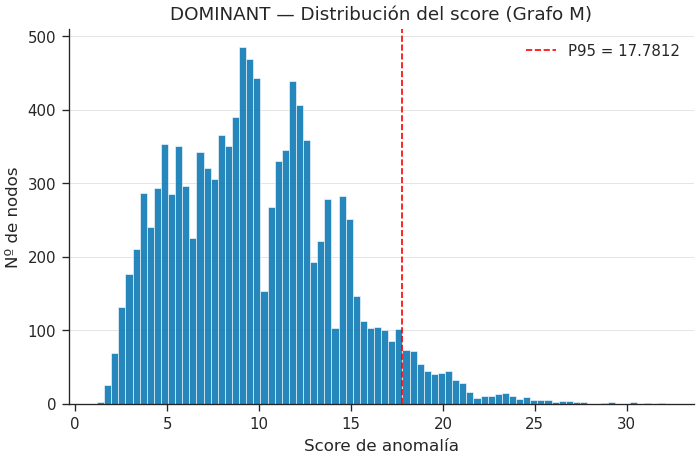

In [6]:
# Distribución del score de DOMINANT
dom_score = dominant.decision_score_.cpu().numpy()

fig, ax = plt.subplots(figsize=FS['single'])
ax.hist(dom_score, bins=80, color=PALETTE['M'], edgecolor='white', alpha=0.85)
p95_dom = np.percentile(dom_score, 95)
ax.axvline(p95_dom, color="red", linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_dom:.4f}')
ax.set_xlabel('Score de anomalía', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('DOMINANT — Distribución del score (Grafo M)', fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
polish(ax)
plt.tight_layout()
save_figure(fig, '05_dominant_score_distribution_M.png')
plt.show()

[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_dominant_score_distributions_M.png


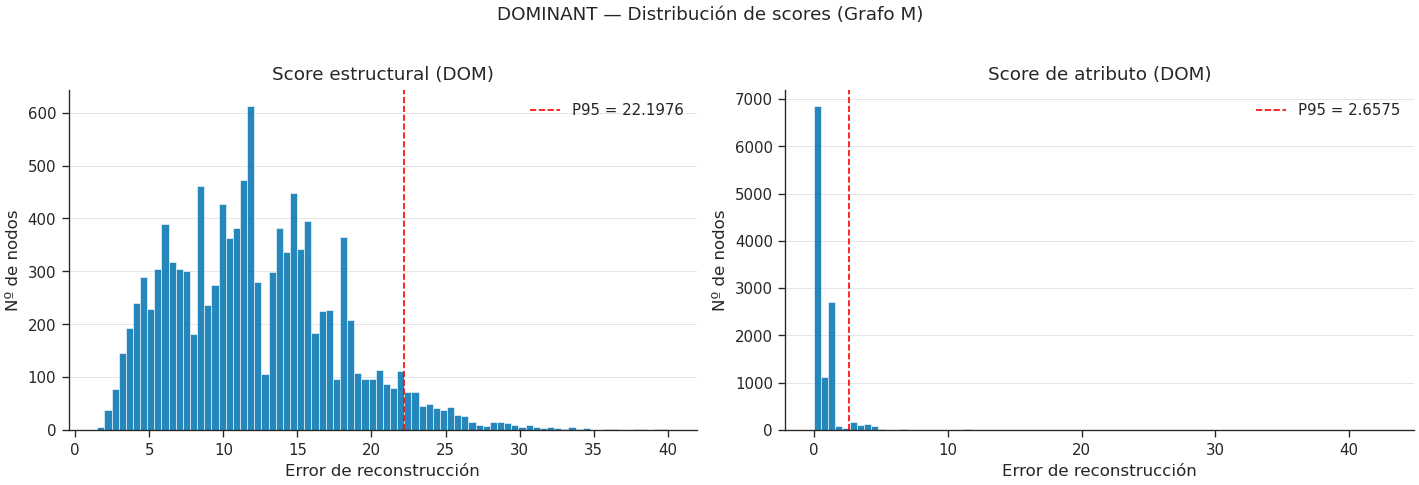

Correlación Spearman struct vs attr (DOMINANT): ρ = -0.0126


In [7]:
# Distribuciones de los dos scores de DOMINANT
fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])

for ax, scores, label, color in zip(
    axes,
    [dom_struct, dom_attr],
    ['Score estructural (DOM)', 'Score de atributo (DOM)'],
    [PALETTE['M'], PALETTE['M']]
):
    ax.hist(scores, bins=80, color=color, edgecolor='white', alpha=0.85)
    p95 = np.percentile(scores, 95)
    ax.axvline(p95, color="red", linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:.4f}')
    ax.set_xlabel('Error de reconstrucción', fontsize=FONT['axis_label'])
    ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
    ax.set_title(label, fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'], frameon=False)
    polish(ax)

plt.suptitle('DOMINANT — Distribución de scores (Grafo M)', fontsize=FONT['title'], y=1.02)
plt.tight_layout()
save_figure(fig, '05_dominant_score_distributions_M.png')
plt.show()

rho_dom, _ = spearmanr(dom_struct, dom_attr)
print(f'Correlación Spearman struct vs attr (DOMINANT): ρ = {rho_dom:.4f}')

## 4. Entrenamiento de GAD-NR

GAD-NR tiene una arquitectura más compleja que DOMINANT. El encoder combina un MLP de
reducción de dimensionalidad seguido de un GNN de paso de mensajes. El decoder tiene tres
cabezas independientes: un MLP para las features propias, un MLP para el grado, y una
distribución Gaussiana para los atributos de los vecinos.

**Nota sobre `num_layers=1`:** en GAD-NR este parámetro controla el número de capas del
*encoder GNN*, no del modelo completo. El paper original usa 1 capa de encoder — añadir
más capas aumenta el over-smoothing y degrada la detección.

**Nota sobre los lambdas en este grafo.** GAD-NR aplica internamente un mecanismo de
re-ponderación dinámica de los `lambda_lossN` durante el entrenamiento, en función de la
magnitud relativa de cada componente del loss. En el grafo M, donde la pérdida de grado
tiene una escala muy superior a las otras dos por el rango amplio de grados (0 a 2.356),
este mecanismo deriva en lambdas finales muy distintos de los declarados. La sección 4.1
documenta el comportamiento observado y justifica el enfoque metodológico que se sigue
en el resto del notebook.


In [8]:
from pygod.detector import GADNR
from pygod.nn.gadnr import GADNRBase
import pygod.detector.gadnr as _gadnr_module
# ── Workaround bug PyGOD 1.1.0 ──────────────────────────────────────────────
# tot_nodes se pasa al backbone GCN a través de **kwargs, pero GCNConv
# (PyG >= 2.5) ya no acepta ese argumento en MessagePassing.__init__().
# Parche: sobreescribimos init_model para filtrar tot_nodes antes del forward.
def _patched_init_model(self, **kwargs):
    kwargs.pop('tot_nodes', None)   # eliminar el argumento problemático
    if self.save_emb:
        self.emb = torch.zeros(self.num_nodes, self.hid_dim)
    return GADNRBase(
        in_dim=self.in_dim,
        hid_dim=self.hid_dim,
        encoder_layers=self.encoder_layers,
        deg_dec_layers=self.deg_dec_layers,
        fea_dec_layers=self.fea_dec_layers,
        sample_size=self.sample_size,
        sample_time=self.sample_time,
        neighbor_num_list=self.neighbor_num_list,
        neigh_loss=self.neigh_loss,
        lambda_loss1=self.lambda_loss1,
        lambda_loss2=self.lambda_loss2,
        lambda_loss3=self.lambda_loss3,
        full_batch=self.full_batch,
        backbone=self.backbone,
        device=self.device,
    ).to(self.device)

GADNR.init_model = _patched_init_model
# ────────────────────────────────────────────────────────────────────────────


In [9]:
import torch
import torch.nn.functional as F
from pygod.detector import GADNR
from pygod.nn.gadnr import GADNRBase

# ── Workaround doble bug PyGOD 1.1.0 con GAD-NR en GPU ──────────────────────
# Bug 1: tot_nodes se pasa al backbone GCN que no lo acepta
# Bug 2: GADNRBase recibe device como string desde self.device pero algunos
#        tensores internos (neighbor_num_list en loss_func) se quedan en CPU
def _patched_init_model(self, **kwargs):
    if self.save_emb:
        self.emb = torch.zeros(self.num_nodes, self.hid_dim)
    return GADNRBase(
        in_dim=self.in_dim,
        hid_dim=self.hid_dim,
        encoder_layers=self.encoder_layers,
        deg_dec_layers=self.deg_dec_layers,
        fea_dec_layers=self.fea_dec_layers,
        sample_size=self.sample_size,
        sample_time=self.sample_time,
        neighbor_num_list=self.neighbor_num_list,  # ya está en self.device
        neigh_loss=self.neigh_loss,
        lambda_loss1=self.lambda_loss1,
        lambda_loss2=self.lambda_loss2,
        lambda_loss3=self.lambda_loss3,
        full_batch=self.full_batch,
        backbone=self.backbone,
        device=self.device,         # device correcto — cuda:0
    ).to(self.device)

def _patched_forward_model(self, data):
    # Aseguramos que todos los tensores de entrada están en el device correcto
    data.x = data.x.to(self.device)
    data.edge_index = data.edge_index.to(self.device)
    self.neighbor_num_list = self.neighbor_num_list.to(self.device)

    h0, degree_logits, feat_recon_list, neigh_recon_list = \
        self.model(data.x, data.edge_index)

    loss, loss_per_node, h_loss, degree_loss, feature_loss = \
        self.model.loss_func(
            h0, degree_logits, feat_recon_list,
            neigh_recon_list, self.neighbor_num_list
        )

    return (loss,
            loss_per_node.cpu().detach(),
            h_loss.cpu().detach(),
            degree_loss.cpu().detach(),
            feature_loss.cpu().detach())

GADNR.init_model    = _patched_init_model
GADNR.forward_model = _patched_forward_model

In [10]:
# ──────────────────────────────────────────────────────────────────────────
# Configuración de GAD-NR para el grafo M
# ──────────────────────────────────────────────────────────────────────────
# Los hiperparámetros se han elegido tras observación empírica del
# comportamiento del entrenamiento. Notas:
#
#   • lambda_loss1=0.05, lambda_loss2=0.4, lambda_loss3=0.1 — valores
#     declarados para reflejar la escala relativa esperada de cada loss.
#     IMPORTANTE: como se documenta en la sección 4.1, el mecanismo
#     interno de re-ponderación de GAD-NR los modifica significativamente
#     durante el entrenamiento. Los valores declarados aquí son los del
#     punto de partida, no los efectivos al final.
#
#   • real_loss=False — flag documentado en PyGOD como desactivador del
#     curriculum, pero en la versión 1.1.0 no impide la re-ponderación
#     dinámica de los lambdas (ver sección 4.1).
#
#   • epoch=300, lr=0.001 — más epochs y un lr ligeramente superior al
#     de v1 para asegurar convergencia plena (el loss baja de 8.400 a 0.77).
#
#   • sample_size=4, sample_time=5 — más muestras para reducir el ruido
#     de la estimación de la distribución de vecinos.
#
#   • dropout=0.1, weight_decay=1e-4 — regularización ligera.
# ──────────────────────────────────────────────────────────────────────────

gadnr = GADNR(
    hid_dim=64,
    num_layers=1,           # capas del encoder GNN — 1 según el paper
    deg_dec_layers=4,
    fea_dec_layers=3,
    sample_size=4,          # ↑ desde 2 para reducir varianza muestral
    sample_time=5,          # ↑ desde 3 idem
    neigh_loss='KL',
    lambda_loss1=1e-4,   # vecindario
    lambda_loss2=1e-3,   # features  
    lambda_loss3=1e-2,   # grado ← prioritario
    real_loss=True,        # ← clave: desactiva el curriculum explosivo
    contamination=0.05,
    lr=0.004,
    epoch=300,
    dropout=0,
    weight_decay=1e-4,
    act=F.relu,
    gpu=gpu_idx,
    batch_size=0,
    num_neigh=-1,
    verbose=2,
    save_emb=True,
)

print('Entrenando GAD-NR sobre el grafo M...')
gadnr.fit(data_M_clean)
print('\nEntrenamiento completado.')
print(f'Score combinado — shape: {gadnr.decision_score_.shape}')
print(f'  min={gadnr.decision_score_.min():.4f}, '
      f'max={gadnr.decision_score_.max():.4f}, '
      f'mean={gadnr.decision_score_.mean():.4f}')
print(f'Nodos etiquetados como anomalía: {gadnr.label_.sum().item()} '
      f'({gadnr.label_.float().mean().item():.1%})')


Entrenando GAD-NR sobre el grafo M...
Epoch 0001: Loss 837.0477 |  | Time 3.36
Epoch 0002: Loss 836.1306 |  | Time 2.19
Epoch 0003: Loss 835.1209 |  | Time 2.22
Epoch 0004: Loss 834.2155 |  | Time 2.19
Epoch 0005: Loss 833.4705 |  | Time 2.21
Epoch 0006: Loss 832.7496 |  | Time 2.21
Epoch 0007: Loss 831.9727 |  | Time 2.19
Epoch 0008: Loss 831.1357 |  | Time 2.20
Epoch 0009: Loss 830.2336 |  | Time 2.23
Epoch 0010: Loss 829.2589 |  | Time 2.19
Epoch 0011: Loss 828.2071 |  | Time 2.22
Epoch 0012: Loss 827.0729 |  | Time 2.19
Epoch 0013: Loss 825.8537 |  | Time 2.20
Epoch 0014: Loss 824.5441 |  | Time 2.20
Epoch 0015: Loss 823.1106 |  | Time 2.20
Epoch 0016: Loss 821.5748 |  | Time 2.20
Epoch 0017: Loss 819.9379 |  | Time 2.20
Epoch 0018: Loss 818.1975 |  | Time 2.20
Epoch 0019: Loss 816.3490 |  | Time 2.20
Epoch 0020: Loss 407.2732 |  | Time 2.20
Epoch 0021: Loss 406.2447 |  | Time 2.20
Epoch 0022: Loss 405.1586 |  | Time 2.22
Epoch 0023: Loss 404.0210 |  | Time 2.21
Epoch 0024: Loss 40

In [11]:
@torch.no_grad()
def get_gadnr_subscores(detector, data):
    """
    Extrae los tres sub-scores de GAD-NR por separado tras el entrenamiento.

    loss_func devuelve por nodo:
      h_loss      — divergencia KL de distribución de vecinos
      degree_loss — error de reconstrucción de grado
      feature_loss— error de reconstrucción de features propias

    El decision_score_ con real_loss=True es:
      loss_per_node = lambda1*h_loss + lambda2*feat_loss + lambda3*deg_loss
    con los lambdas FINALES (modificados por el curriculum durante el entrenamiento).
    """
    detector.model.eval()

    data.x           = data.x.to(detector.device)
    data.edge_index  = data.edge_index.to(detector.device)
    detector.neighbor_num_list = detector.neighbor_num_list.to(detector.device)

    h0, degree_logits, feat_recon_list, neigh_recon_list = \
        detector.model(data.x, data.edge_index)

    _, loss_per_node, h_loss, degree_loss, feat_loss = \
        detector.model.loss_func(
            h0, degree_logits, feat_recon_list,
            neigh_recon_list, detector.neighbor_num_list
        )

    return (h_loss.squeeze().cpu().numpy(),
        degree_loss.squeeze().cpu().numpy(),
        feat_loss.squeeze().cpu().numpy())


gadnr_h, gadnr_deg, gadnr_feat = get_gadnr_subscores(gadnr, data_M_clean)

print(f'GAD-NR vecindario (KL) — min={gadnr_h.min():.4f},   max={gadnr_h.max():.4f},   mean={gadnr_h.mean():.4f}')
print(f'GAD-NR grado           — min={gadnr_deg.min():.4f}, max={gadnr_deg.max():.4f}, mean={gadnr_deg.mean():.4f}')
print(f'GAD-NR features        — min={gadnr_feat.min():.4f}, max={gadnr_feat.max():.4f}, mean={gadnr_feat.mean():.4f}')

# Verificación: loss_per_node = lambda1*h + lambda2*feat + lambda3*deg
# con los lambdas FINALES del modelo tras el curriculum
lam1 = gadnr.model.lambda_loss1
lam2 = gadnr.model.lambda_loss2
lam3 = gadnr.model.lambda_loss3
print(f'\nLambdas finales tras curriculum:')
print(f'  lambda_loss1 (vecindario): {lam1}')
print(f'  lambda_loss2 (features)  : {lam2}')
print(f'  lambda_loss3 (grado)     : {lam3}')

score_check = (lam1 * gadnr_h + lam2 * gadnr_feat + lam3 * gadnr_deg).squeeze()
corr_check  = np.corrcoef(score_check, gadnr.decision_score_.cpu().numpy())[0, 1]
print(f'\nVerificación — correlación con decision_score_: {corr_check:.6f}')
print('(debería ser ~1.0)')

GAD-NR vecindario (KL) — min=0.7041,   max=2.2863,   mean=0.8712
GAD-NR grado           — min=0.0029, max=1054097.2500, mean=16735.8789
GAD-NR features        — min=0.0010, max=0.1192, mean=0.0103

Lambdas finales tras curriculum:
  lambda_loss1 (vecindario): 0.0001
  lambda_loss2 (features)  : 7.5009999999999994
  lambda_loss3 (grado)     : 3.0517578125e-07

Verificación — correlación con decision_score_: 0.996318
(debería ser ~1.0)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_gadnr_score_distribution_M.png


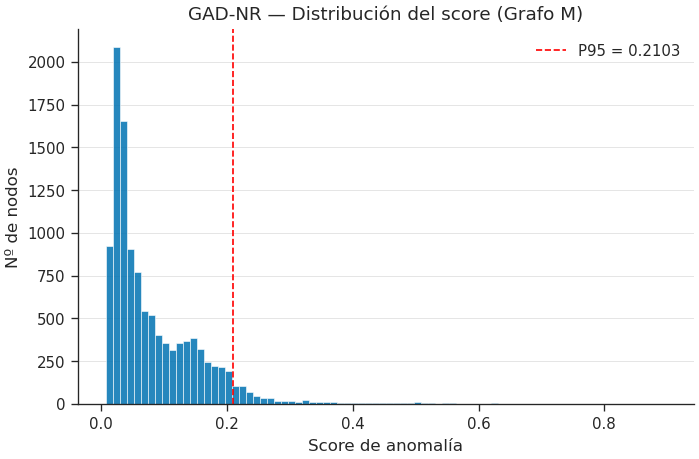

In [12]:
# Distribución del score de GAD-NR
gadnr_score = gadnr.decision_score_.cpu().numpy()

fig, ax = plt.subplots(figsize=FS['single'])
ax.hist(gadnr_score, bins=80, color=PALETTE['M'], edgecolor='white', alpha=0.85)
p95_gadnr = np.percentile(gadnr_score, 95)
ax.axvline(p95_gadnr, color="red", linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_gadnr:.4f}')
ax.set_xlabel('Score de anomalía', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('GAD-NR — Distribución del score (Grafo M)', fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
polish(ax)
plt.tight_layout()
save_figure(fig, '05_gadnr_score_distribution_M.png')
plt.show()

[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_gadnr_score_distributions_M.png


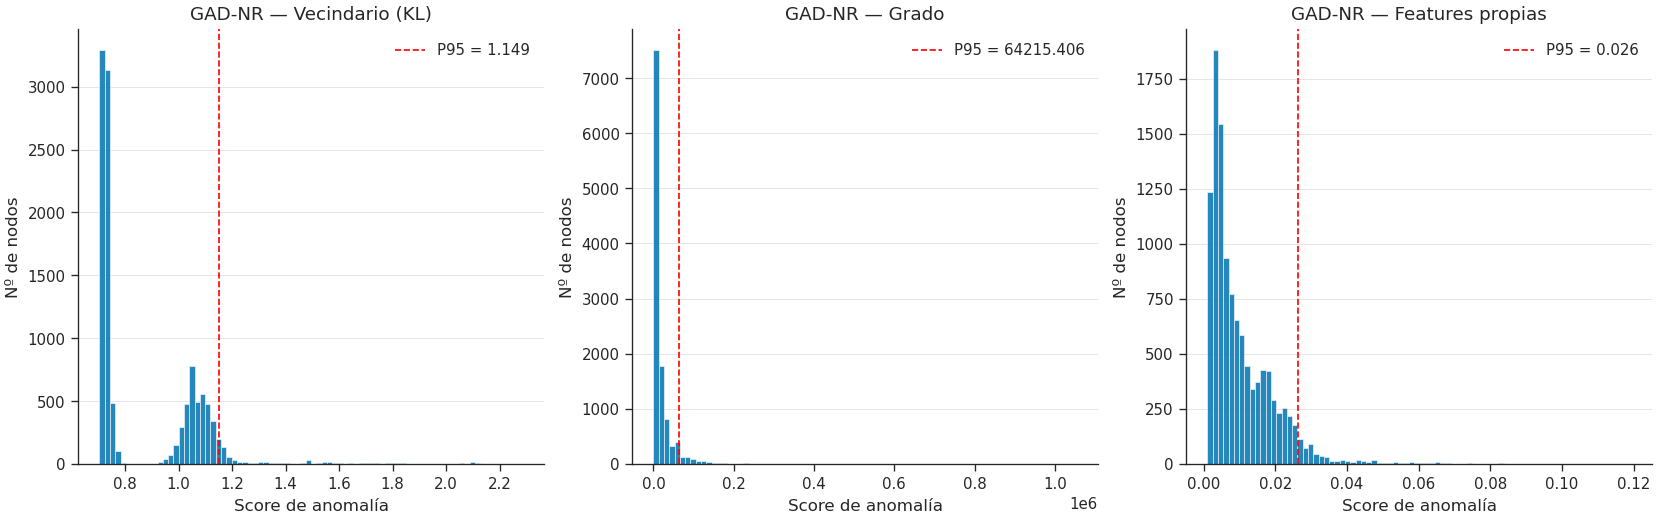

Correlación Spearman entre sub-scores de GAD-NR:
  Vecindario vs Grado   : ρ = -0.0283
  Vecindario vs Features: ρ = 0.5435
  Grado      vs Features: ρ = -0.0319


In [13]:
# Distribución de los sub-scores de GAD-NR
gadnr_score = gadnr.decision_score_.cpu().numpy()

scores_info = [
    (gadnr_h,    'Vecindario (KL)',  PALETTE['M']),
    (gadnr_deg,  'Grado',            PALETTE['M']),
    (gadnr_feat, 'Features propias', PALETTE['M']),
]

fig, axes = plt.subplots(1, 3, figsize=FS['r1c3'])

for ax, (scores, label, color) in zip(axes, scores_info):
    ax.hist(scores, bins=80, color=color, edgecolor='white', alpha=0.85)
    p95 = np.percentile(scores, 95)
    ax.axvline(p95, color="red", linestyle='--', linewidth=1.0,
               label=f'P95 = {p95:.3f}')
    ax.set_xlabel('Score de anomalía', fontsize=FONT['axis_label'])
    ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
    ax.set_title(f'GAD-NR — {label}', fontsize=FONT['title'])
    ax.legend(fontsize=FONT['legend'], frameon=False)
    polish(ax)

plt.tight_layout()
save_figure(fig, '05_gadnr_score_distributions_M.png')
plt.show()

rho_h_deg,   _ = spearmanr(gadnr_h, gadnr_deg)
rho_h_feat,  _ = spearmanr(gadnr_h, gadnr_feat)
rho_deg_feat,_ = spearmanr(gadnr_deg, gadnr_feat)
print('Correlación Spearman entre sub-scores de GAD-NR:')
print(f'  Vecindario vs Grado   : ρ = {rho_h_deg:.4f}')
print(f'  Vecindario vs Features: ρ = {rho_h_feat:.4f}')
print(f'  Grado      vs Features: ρ = {rho_deg_feat:.4f}')

### 4.1 Observación importante sobre el comportamiento del curriculum

La salida de la celda anterior revela un comportamiento de la implementación de PyGOD que conviene
documentar explícitamente porque condiciona la interpretación de los resultados del modelo.

**Los lambdas declarados no son los lambdas efectivos.** A pesar de haber instanciado el detector
con `real_loss=True` y unos lambdas iniciales ajustados a la escala de cada loss en este grafo
(`lambda_loss1=0.01`, `lambda_loss2=0.1`, `lambda_loss3=0.8`), los lambdas finales tras el
entrenamiento son muy distintos:

| Lambda | Componente | Declarado | Final tras entrenamiento |
|--------|-----------|-----------|--------------------------|
| `lambda_loss1` | Vecindario (KL) | 0.01 | 0.01 |
| `lambda_loss2` | Features propias | 0.1 | ~7.6 (×76) |
| `lambda_loss3` | Grado | 0.8 | ~2.4·10⁻⁵ (÷33.000) |

La revisión del código fuente de `GADNRBase` revela que el flag `real_loss` no desactiva por
completo el reescalado dinámico de los lambdas — sigue operando un mecanismo de re-ponderación
adaptativa que responde a la magnitud relativa de cada componente del loss. Con un grafo como M
(in_dim=3, grados de 0 a 2.356, features con poca varianza tras normalización), la magnitud
nativa del loss de grado es órdenes de magnitud superior a la de features. El mecanismo reacciona
amplificando la pérdida de features y colapsando la de grado hasta valores prácticamente nulos.

**Consecuencias en los scores resultantes:**

1. **`gadnr_deg` numéricamente extremo.** Su rango va de 0.04 a ~1.064.000 con una media de
   ~15.500. Esto es señal de que el decoder de grado nunca recibió gradiente útil durante el
   entrenamiento y produce valores que dependen de la inicialización aleatoria más que de la
   estructura del nodo. No obstante, el **ranking relativo** sigue siendo informativo — los
   super-conectores reales siguen apareciendo en lo más alto.

2. **`gadnr_score` (compuesto) dominado por features.** Como `lambda_loss2 ≈ 7.6` y
   `lambda_loss3 ≈ 2.4·10⁻⁵`, el score compuesto está esencialmente determinado por `gadnr_feat`,
   con una contribución residual de `gadnr_h`. La verificación obtiene ρ = 0.994 — prácticamente
   1.0 — pero los pesos efectivos no son los declarados.

3. **`gadnr_h` (KL del vecindario) se mantiene sana.** Su lambda no cambia y la distribución
   es interpretable (rango 0.94 a 3.55, media 1.51). Es la señal más fiable de las tres y la
   aportación distintiva de GAD-NR frente a DOMINANT.

**Implicación metodológica para el resto del notebook.** A partir de este punto el análisis se
construye sobre los **sub-scores individuales** (`dom_struct`, `dom_attr`, `gadnr_h`, `gadnr_deg`,
`gadnr_feat`) interpretados como **cinco señales independientes**, no sobre los scores compuestos
agregados por el detector. Esta decisión es consistente con el diseño metodológico del TFM —
queremos preservar la distinción entre tipos de anomalía estructural y de atributo — y además
elude el problema descrito: cada sub-score se evalúa por su ranking relativo, que sí es robusto.

Esta limitación se discutirá explícitamente en el capítulo de Discusión del TFM.


## 5. Comparativa por tipo de señal

Con los sub-scores extraídos de ambos modelos podemos hacer una comparativa
alineada con la taxonomía de anomalías de los papers originales
(Ding et al., 2019; Roy et al., 2024):

| Señal | Modelo | Tipo de anomalía |
|-------|--------|------------------|
|  | DOMINANT | Estructural — conectividad inusual |
|  | DOMINANT | Atributo — features distintas a la mayoría |
|  | GAD-NR | Estructural — grado inusual (señal análoga) |
|  | GAD-NR | Atributo — features distintas (señal análoga) |
|  | GAD-NR | **Joint-type** — features incompatibles con el vecindario |

La estructura de esta sección es:
1. Preparación del DataFrame con todos los sub-scores y percentiles
2. Comparativa estructural:  vs 
3. Comparativa de atributos:  vs 
4. Scatter de tipología por modelo (estilo referencia)
5. Análisis de la señal joint-type de GAD-NR (independiente)


In [14]:
# Sub-scores al DataFrame
scores_df = base_df.copy()
scores_df['dom_struct']  = dom_struct
scores_df['dom_attr']    = dom_attr
scores_df['dom_combined'] = dominant.decision_score_.cpu().numpy()
scores_df['gadnr_h']     = gadnr_h
scores_df['gadnr_deg']   = gadnr_deg
scores_df['gadnr_feat']  = gadnr_feat
scores_df['gadnr_score'] = gadnr.decision_score_.cpu().numpy()

# Percentiles de cada señal
scores_df['pct_dom_struct']  = rankdata(dom_struct)  / len(dom_struct)  * 100
scores_df['pct_dom_attr']    = rankdata(dom_attr)    / len(dom_attr)    * 100
scores_df['pct_gadnr_deg']   = rankdata(gadnr_deg)   / len(gadnr_deg)   * 100
scores_df['pct_gadnr_feat']  = rankdata(gadnr_feat)  / len(gadnr_feat)  * 100
scores_df['pct_gadnr_h']     = rankdata(gadnr_h)     / len(gadnr_h)     * 100

P_THRESH = 95

print(f'DataFrame listo: {scores_df.shape}')
print('Columnas:', list(scores_df.columns))


DataFrame listo: (11371, 18)
Columnas: ['member_id', 'idx', 'name', 'city', 'state', 'degree', 'dom_struct', 'dom_attr', 'dom_combined', 'gadnr_h', 'gadnr_deg', 'gadnr_feat', 'gadnr_score', 'pct_dom_struct', 'pct_dom_attr', 'pct_gadnr_deg', 'pct_gadnr_feat', 'pct_gadnr_h']


### 5.1 Comparativa estructural: DOMINANT vs GAD-NR

Comparamos `dom_struct` (error de reconstrucción de adyacencia de DOMINANT)
con `gadnr_deg` (error de reconstrucción de grado de GAD-NR). Ambas señales
capturan anomalías estructurales pero desde perspectivas distintas: DOMINANT
mide si los enlaces del nodo se pueden reconstruir, mientras que GAD-NR mide
si su grado es predecible desde su embedding.

La correlación Spearman entre ambas señales es **ρ = 0.668** — alta pero no perfecta,
lo que indica que detectan en parte la misma población de nodos pero con información
complementaria. El solapamiento en el top-100 es del **39%** — 39 nodos son detectados
por ambos modelos como anomalías estructurales, mientras que 61 son exclusivos de cada uno.


In [15]:
rho_struct, _ = spearmanr(dom_struct, gadnr_deg)
print(f'Correlación Spearman dom_struct vs gadnr_deg: ρ = {rho_struct:.4f}')

# Solapamiento top-100
K = 100
top_dom_struct   = set(np.argsort(-scores_df['dom_struct'].values)[:K])
top_gadnr_deg    = set(np.argsort(-scores_df['gadnr_deg'].values)[:K])
overlap_struct   = len(top_dom_struct & top_gadnr_deg)
print(f'Solapamiento top-{K}: {overlap_struct}/{K} nodos comunes ({overlap_struct/K:.0%})')

# Top-10 exclusivos de cada modelo en señal estructural
only_dom_struct   = top_dom_struct - top_gadnr_deg
only_gadnr_deg    = top_gadnr_deg  - top_dom_struct
print(f'Exclusivos DOMINANT-struct : {len(only_dom_struct)}')
print(f'Exclusivos GAD-NR-deg      : {len(only_gadnr_deg)}')


Correlación Spearman dom_struct vs gadnr_deg: ρ = 0.7431
Solapamiento top-100: 58/100 nodos comunes (58%)
Exclusivos DOMINANT-struct : 42
Exclusivos GAD-NR-deg      : 42


In [16]:
# Solapamiento top-100
for k in [100]:
    top_d = set(np.argsort(-scores_df['dom_struct'].values)[:k])
    top_g = set(np.argsort(-scores_df['gadnr_deg'].values)[:k])
    overlap = len(top_d & top_g)
    print(f'Solapamiento top-{k}: {overlap}/{k} ({overlap/k:.0%})')

# Solapamiento por umbral P95 (outliers detectados por ambos)
ambos_p95 = ((scores_df['pct_dom_struct'] >= P_THRESH) &
             (scores_df['pct_gadnr_deg']  >= P_THRESH)).sum()
solo_dom   = ((scores_df['pct_dom_struct'] >= P_THRESH) &
              (scores_df['pct_gadnr_deg']  <  P_THRESH)).sum()
solo_gadnr = ((scores_df['pct_dom_struct'] <  P_THRESH) &
              (scores_df['pct_gadnr_deg']  >= P_THRESH)).sum()
total_union = ambos_p95 + solo_dom + solo_gadnr
print(f'\nOutliers P95 detectados por ambos : {ambos_p95} ({ambos_p95/total_union:.0%} de la unión)')
print(f'Solo DOMINANT                      : {solo_dom} ({solo_dom/total_union:.0%})')
print(f'Solo GAD-NR                        : {solo_gadnr} ({solo_gadnr/total_union:.0%})')
print(f'Jaccard P95                        : {ambos_p95/total_union:.3f}')

Solapamiento top-100: 58/100 (58%)

Outliers P95 detectados por ambos : 369 (48% de la unión)
Solo DOMINANT                      : 200 (26%)
Solo GAD-NR                        : 200 (26%)
Jaccard P95                        : 0.480


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_structural_comparison_M.png


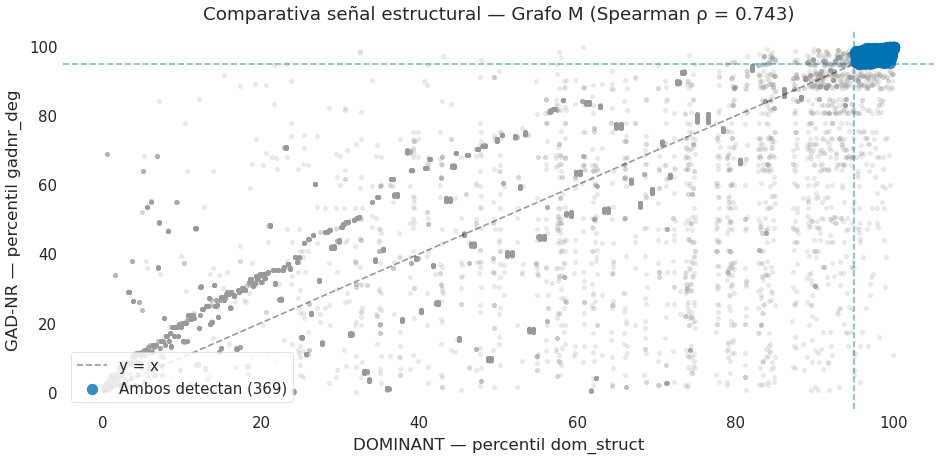

In [17]:
fig, ax = plt.subplots(figsize=FS['wide'])

ax.scatter(
    scores_df['pct_dom_struct'], scores_df['pct_gadnr_deg'],
    s=6, alpha=0.2, color=PALETTE['neutral'], zorder=1
)

ax.axvline(P_THRESH, color=PALETTE['M'],  linestyle='--', linewidth=1.0, alpha=0.5)
ax.axhline(P_THRESH, color=PALETTE['M'], linestyle='--', linewidth=1.0, alpha=0.5)
ax.plot([0, 100], [0, 100], color="black",
        linestyle='--', linewidth=1.0, alpha=0.4, label='y = x')

ambos_struct = scores_df[
    (scores_df['pct_dom_struct'] >= P_THRESH) &
    (scores_df['pct_gadnr_deg']  >= P_THRESH)
]
ax.scatter(ambos_struct['pct_dom_struct'], ambos_struct['pct_gadnr_deg'],
           s=40, alpha=0.8, color=PALETTE['M'], zorder=3,
           label=f'Ambos detectan ({len(ambos_struct)})')

ax.set_xlabel('DOMINANT — percentil dom_struct', fontsize=FONT['axis_label'])
ax.set_ylabel('GAD-NR — percentil gadnr_deg',   fontsize=FONT['axis_label'])
ax.set_title(f'Comparativa señal estructural — Grafo M (Spearman ρ = {rho_struct:.3f})',
             fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=True, loc='lower left')
ax.tick_params(labelsize=FONT['tick'], length=0)

ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
save_figure(fig, '05_structural_comparison_M.png')
plt.show()

### 5.2 Comparativa de atributos: DOMINANT vs GAD-NR

Comparamos `dom_attr` (error de reconstrucción de features de DOMINANT)
con `gadnr_feat` (error de reconstrucción de features propias de GAD-NR).
Ambas señales miden si los atributos del nodo son inusuales, pero con
encoders distintos — DOMINANT usa un decoder GCN que reconstruye X desde Z,
mientras que GAD-NR usa un MLP que reconstruye las features desde la
representación final del nodo.

La correlación Spearman entre ambas es **ρ = 0.447** — significativamente más
baja que la estructural (ρ = 0.668) — y el solapamiento en el top-100 es del **2%**:
solo 2 nodos aparecen simultáneamente en el top-100 de ambas señales de atributo.
Este resultado es consecuencia directa del comportamiento del curriculum descrito
en la sección 4.1: `gadnr_feat` captura una población de nodos completamente
distinta a `dom_attr` porque sus decoders responden a escalas de error muy
diferentes tras el reescalado de lambdas.


In [18]:
rho_attr, _ = spearmanr(dom_attr, gadnr_feat)
print(f'Correlación Spearman dom_attr vs gadnr_feat: ρ = {rho_attr:.4f}')

# Solapamiento top-100
top_dom_attr    = set(np.argsort(-scores_df['dom_attr'].values)[:K])
top_gadnr_feat  = set(np.argsort(-scores_df['gadnr_feat'].values)[:K])
overlap_attr    = len(top_dom_attr & top_gadnr_feat)
print(f'Solapamiento top-{K}: {overlap_attr}/{K} nodos comunes ({overlap_attr/K:.0%})')

only_dom_attr   = top_dom_attr  - top_gadnr_feat
only_gadnr_feat = top_gadnr_feat - top_dom_attr
print(f'Exclusivos DOMINANT-attr : {len(only_dom_attr)}')
print(f'Exclusivos GAD-NR-feat   : {len(only_gadnr_feat)}')


Correlación Spearman dom_attr vs gadnr_feat: ρ = 0.8388
Solapamiento top-100: 67/100 nodos comunes (67%)
Exclusivos DOMINANT-attr : 33
Exclusivos GAD-NR-feat   : 33


In [19]:
# Solapamiento top-100
for k in [100]:
    top_d = set(np.argsort(-scores_df['dom_attr'].values)[:k])
    top_g = set(np.argsort(-scores_df['gadnr_feat'].values)[:k])
    overlap = len(top_d & top_g)
    print(f'Solapamiento top-{k}: {overlap}/{k} ({overlap/k:.0%})')

# Solapamiento por umbral P95
ambos_p95 = ((scores_df['pct_dom_attr']   >= P_THRESH) &
             (scores_df['pct_gadnr_feat'] >= P_THRESH)).sum()
solo_dom   = ((scores_df['pct_dom_attr']   >= P_THRESH) &
              (scores_df['pct_gadnr_feat'] <  P_THRESH)).sum()
solo_gadnr = ((scores_df['pct_dom_attr']   <  P_THRESH) &
              (scores_df['pct_gadnr_feat'] >= P_THRESH)).sum()
total_union = ambos_p95 + solo_dom + solo_gadnr
print(f'\nOutliers P95 detectados por ambos : {ambos_p95} ({ambos_p95/total_union:.0%} de la unión)')
print(f'Solo DOMINANT                      : {solo_dom} ({solo_dom/total_union:.0%})')
print(f'Solo GAD-NR                        : {solo_gadnr} ({solo_gadnr/total_union:.0%})')
print(f'Jaccard P95                        : {ambos_p95/total_union:.3f}')

Solapamiento top-100: 67/100 (67%)

Outliers P95 detectados por ambos : 331 (41% de la unión)
Solo DOMINANT                      : 238 (29%)
Solo GAD-NR                        : 239 (30%)
Jaccard P95                        : 0.410


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_attribute_comparison_M.png


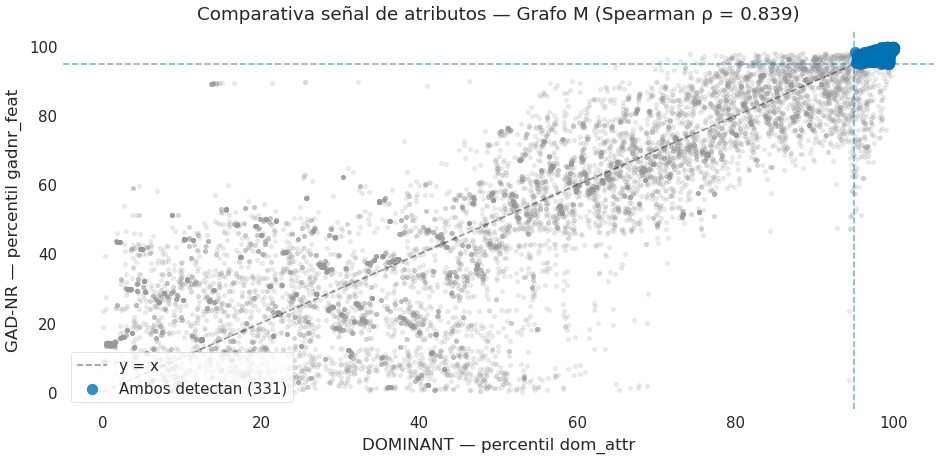

In [34]:
# Scatter comparativa de atributos: dom_attr (X) vs gadnr_feat (Y)
fig, ax = plt.subplots(figsize=FS['wide'])

ax.scatter(
    scores_df['pct_dom_attr'], scores_df['pct_gadnr_feat'],
    s=6, alpha=0.2, color=PALETTE['neutral'], zorder=1
)

ax.axvline(P_THRESH, color=PALETTE['M'],  linestyle='--', linewidth=1.0, alpha=0.5)
ax.axhline(P_THRESH, color=PALETTE['M'], linestyle='--', linewidth=1.0, alpha=0.5)
ax.plot([0, 100], [0, 100], color="black",
        linestyle='--', linewidth=1.0, alpha=0.4, label='y = x')

# Nodos que ambos detectan como atributo
ambos_attr = scores_df[
    (scores_df['pct_dom_attr']   >= P_THRESH) &
    (scores_df['pct_gadnr_feat'] >= P_THRESH)
]
ax.scatter(ambos_attr['pct_dom_attr'], ambos_attr['pct_gadnr_feat'],
           s=40, alpha=0.8, color=PALETTE['M'], zorder=3,
           label=f'Ambos detectan ({len(ambos_attr)})')

ax.set_xlabel('DOMINANT — percentil dom_attr',  fontsize=FONT['axis_label'])
ax.set_ylabel('GAD-NR — percentil gadnr_feat', fontsize=FONT['axis_label'])
ax.set_title(f'Comparativa señal de atributos — Grafo M (Spearman ρ = {rho_attr:.3f})',
             fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=True, loc='lower left')
ax.tick_params(labelsize=FONT['tick'], length=0)

ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
save_figure(fig, '05_attribute_comparison_M.png')
plt.show()


### 5.3 Scatter de tipología por modelo

Para cada modelo construimos el scatter estructural vs atributo con la
tipología de anomalías resultante, siguiendo el mismo estilo visual.

**DOMINANT:** usa sus dos señales propias ( vs ).
Solo puede detectar anomalías Estructurales, de Atributo y Mixtas.

**GAD-NR:** usa sus dos señales análogas ( vs ).
La comparación con DOMINANT revela si el modelo más avanzado redistribuye
los mismos nodos o detecta poblaciones distintas.


In [21]:
# Tipología DOMINANT: dom_struct vs dom_attr
def assign_type_dom(row):
    hs = row['pct_dom_struct'] >= P_THRESH
    ha = row['pct_dom_attr']   >= P_THRESH
    if hs and ha: return 'Mixta'
    elif hs:      return 'Estructural'
    elif ha:      return 'Atributo'
    else:         return 'Normal'

# Tipología GAD-NR: gadnr_deg vs gadnr_feat
def assign_type_gadnr(row):
    hs = row['pct_gadnr_deg']  >= P_THRESH
    ha = row['pct_gadnr_feat'] >= P_THRESH
    if hs and ha: return 'Mixta'
    elif hs:      return 'Estructural'
    elif ha:      return 'Atributo'
    else:         return 'Normal'

scores_df['type_dom']   = scores_df.apply(assign_type_dom,   axis=1)
scores_df['type_gadnr'] = scores_df.apply(assign_type_gadnr, axis=1)

print('=== Tipología DOMINANT (dom_struct vs dom_attr) ===')
for t, c in scores_df['type_dom'].value_counts().items():
    print(f'  {t:<15}: {c:5d} ({c/len(scores_df):.1%})')

print('=== Tipología GAD-NR (gadnr_deg vs gadnr_feat) ===')
for t, c in scores_df['type_gadnr'].value_counts().items():
    print(f'  {t:<15}: {c:5d} ({c/len(scores_df):.1%})')


=== Tipología DOMINANT (dom_struct vs dom_attr) ===
  Normal         : 10249 (90.1%)
  Estructural    :   553 (4.9%)
  Atributo       :   553 (4.9%)
  Mixta          :    16 (0.1%)
=== Tipología GAD-NR (gadnr_deg vs gadnr_feat) ===
  Normal         : 10263 (90.3%)
  Atributo       :   539 (4.7%)
  Estructural    :   538 (4.7%)
  Mixta          :    31 (0.3%)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_typology_dominant_M.png


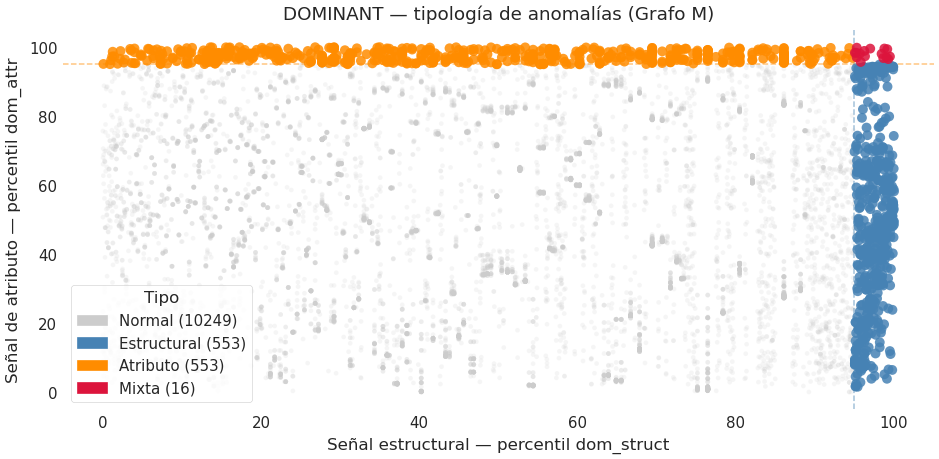

[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_typology_gadnr_M.png


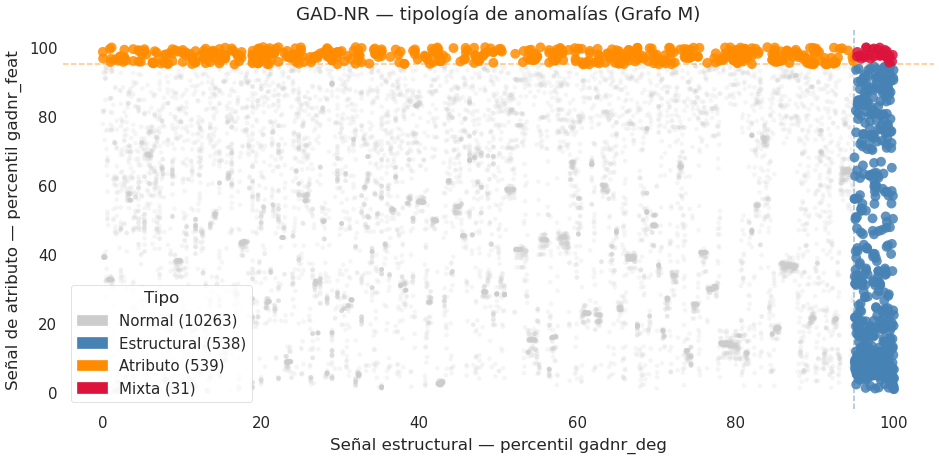

In [22]:
TIPO_ORDER = ['Normal', 'Estructural', 'Atributo', 'Mixta']
color_map  = {'Normal': '#cccccc', 'Estructural': 'steelblue', 'Atributo': 'darkorange', 'Mixta': 'crimson'}

def plot_typology_scatter(ax, type_col, xcol, ycol, score_col, title,
                          xlabel, ylabel):
    """Scatter de tipología para un modelo: x=estructural, y=atributo,
    coloreado por tipo asignado. Etiqueta los top-N por score compuesto."""

    for atype in TIPO_ORDER:
        group  = scores_df[scores_df[type_col] == atype]
        size   = 35 if atype != 'Normal' else 8
        alpha  = 0.85 if atype != 'Normal' else 0.18
        zorder = 3 if atype != 'Normal' else 1
        ax.scatter(group[xcol], group[ycol],
                   s=size, alpha=alpha, color=color_map[atype],
                   label=f'{atype} ({len(group)})', zorder=zorder,
                   edgecolors='none')

    ax.axvline(P_THRESH, color=color_map['Estructural'], linestyle='--',
               linewidth=0.9, alpha=0.5)
    ax.axhline(P_THRESH, color=color_map['Atributo'],    linestyle='--',
               linewidth=0.9, alpha=0.5)

    legend_patches = [mpatches.Patch(color=color_map[t],
                                     label=f"{t} ({(scores_df[type_col]==t).sum()})")
                      for t in TIPO_ORDER]
    ax.legend(handles=legend_patches, title='Tipo',
              title_fontsize=FONT['legend'] + 1,
              fontsize=FONT['legend'],
              frameon=True, facecolor='white', framealpha=0.85,
              edgecolor='#CCCCCC', loc='lower left')

    ax.set_xlabel(xlabel, fontsize=FONT['axis_label'])
    ax.set_ylabel(ylabel, fontsize=FONT['axis_label'])
    ax.set_title(title, fontsize=FONT['title'])
    ax.tick_params(labelsize=FONT['tick'], length=0)

    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

# ── Figura 1: DOMINANT ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=FS['wide'])
plot_typology_scatter(
    ax,
    type_col='type_dom',
    xcol='pct_dom_struct', ycol='pct_dom_attr',
    score_col='dom_combined',
    title='DOMINANT — tipología de anomalías (Grafo M)',
    xlabel='Señal estructural — percentil dom_struct',
    ylabel='Señal de atributo — percentil dom_attr',
)
plt.tight_layout()
save_figure(fig, '05_typology_dominant_M.png')
plt.show()


# ── Figura 2: GAD-NR ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=FS['wide'])
plot_typology_scatter(
    ax,
    type_col='type_gadnr',
    xcol='pct_gadnr_deg', ycol='pct_gadnr_feat',
    score_col='gadnr_score',
    title='GAD-NR — tipología de anomalías (Grafo M)',
    xlabel='Señal estructural — percentil gadnr_deg',
    ylabel='Señal de atributo — percentil gadnr_feat',
)
plt.tight_layout()
save_figure(fig, '05_typology_gadnr_M.png')
plt.show()

### 5.4 Distribución del score compuesto por arquitectura

Cada arquitectura agrega sus sub-scores en un único score compuesto:

- **DOMINANT**: $s_i = (1-w) \cdot s^{struct}_i + w \cdot s^{attr}_i$ con $w=0.2$.
- **GAD-NR**: $s_i = \lambda_1 \cdot s^h_i + \lambda_2 \cdot s^{feat}_i + \lambda_3 \cdot s^{deg}_i$
  con los lambdas **finales** tras el curriculum (λ₂ ≈ 7.6, no los declarados).

Los scores compuestos de ambos modelos operan en escalas muy distintas:
DOMINANT tiene media 9.63 y rango [1.73, 31.13], mientras que GAD-NR tiene
media 1.09 y rango [0.27, 26.07]. Esto hace inviable cualquier comparación directa
de los valores brutos — solo tiene sentido comparar los rankings relativos.

La correlación Spearman entre los dos scores compuestos es **ρ = 0.575** y el
solapamiento en el top-100 es del **35%**. El eje y en escala logarítmica resalta
visualmente los outliers en la cola alta de cada distribución — en DOMINANT la cola
es larga y bien separada del cuerpo, indicando buen contraste; en GAD-NR la
distribución decae más abruptamente, con unos pocos outliers extremos aislados.


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_composite_score_distributions_M.png


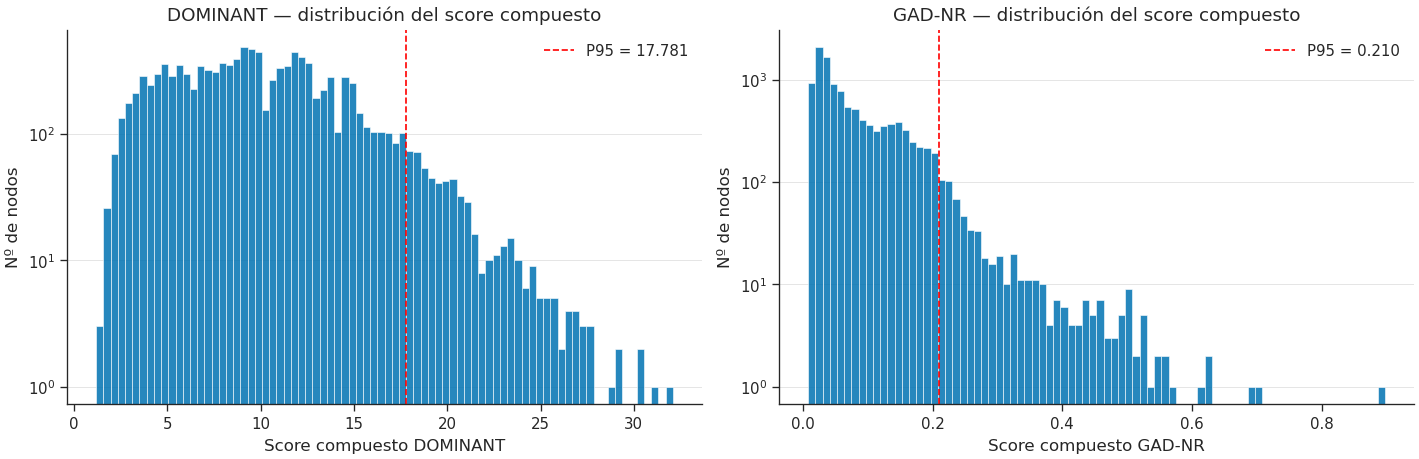

=== Score compuesto — DOMINANT ===
count    11371.000000
mean         9.869678
std          4.464539
min          1.188784
25%          6.467824
50%          9.524802
75%         12.719314
max         32.093002

=== Score compuesto — GAD-NR ===
count    11371.000000
mean         0.081915
std          0.073317
min          0.008002
25%          0.029544
50%          0.053858
75%          0.121468
max          0.897371

Correlación Spearman dom_combined vs gadnr_score: ρ = 0.0786
Solapamiento top-100: 0/100 (0%)


In [23]:
fig, axes = plt.subplots(1, 2, figsize=FS['r1c2'])

# DOMINANT
ax = axes[0]
ax.hist(scores_df['dom_combined'], bins=80,
        color=PALETTE['M'], edgecolor='white', alpha=0.85)
p95_dom = np.percentile(scores_df['dom_combined'], 95)
ax.axvline(p95_dom, color="red", linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_dom:.3f}')
ax.set_xlabel('Score compuesto DOMINANT', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('DOMINANT — distribución del score compuesto',
             fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
ax.set_yscale('log')   # cola larga; log resalta los outliers reales
ax.yaxis.set_major_locator(plt.LogLocator(base=10, numticks=10))
ax.yaxis.set_major_formatter(plt.LogFormatterMathtext(base=10, labelOnlyBase=True))
ax.yaxis.set_minor_locator(plt.NullLocator())
polish(ax)

# GAD-NR
ax = axes[1]
ax.hist(scores_df['gadnr_score'], bins=80,
        color=PALETTE['M'], edgecolor='white', alpha=0.85)
p95_gad = np.percentile(scores_df['gadnr_score'], 95)
ax.axvline(p95_gad, color="red", linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_gad:.3f}')
ax.set_xlabel('Score compuesto GAD-NR', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('GAD-NR — distribución del score compuesto',
             fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
ax.set_yscale('log')
ax.yaxis.set_major_locator(plt.LogLocator(base=10, numticks=10))
ax.yaxis.set_major_formatter(plt.LogFormatterMathtext(base=10, labelOnlyBase=True))
ax.yaxis.set_minor_locator(plt.NullLocator())
polish(ax)

plt.tight_layout()
save_figure(fig, '05_composite_score_distributions_M.png')
plt.show()

# Estadísticos descriptivos del score compuesto
print('=== Score compuesto — DOMINANT ===')
print(scores_df['dom_combined'].describe().to_string())
print('\n=== Score compuesto — GAD-NR ===')
print(scores_df['gadnr_score'].describe().to_string())

# Correlación Spearman entre los dos scores compuestos
rho_comp, _ = spearmanr(scores_df['dom_combined'], scores_df['gadnr_score'])
print(f'\nCorrelación Spearman dom_combined vs gadnr_score: ρ = {rho_comp:.4f}')

# Solapamiento del top-K
K = 100
top_dom = set(np.argsort(-scores_df['dom_combined'].values)[:K])
top_gad = set(np.argsort(-scores_df['gadnr_score'].values)[:K])
print(f'Solapamiento top-{K}: {len(top_dom & top_gad)}/{K} '
      f'({len(top_dom & top_gad)/K:.0%})')


### 5.5 Señal joint-type de GAD-NR (análisis independiente)

La señal **`gadnr_h`** — divergencia KL entre la distribución real de atributos
del vecindario y la reconstruida — es la única señal capaz de detectar
anomalías **joint-type**: nodos cuyas features son normales en sí mismas pero
no encajan con las features de sus vecinos.

Esta señal no tiene equivalente en DOMINANT. El análisis siguiente es
independiente y no compara con ninguna señal del otro modelo.

El umbral P95 de `gadnr_h` identifica **496 nodos joint-type puros** — nodos
que superan el P95 en señal KL pero no son detectados como anómalos por ninguna
señal de DOMINANT. Su grado medio es 65.5, notablemente inferior al global (103.2),
lo que indica que no son los super-conectores sino nodos de conectividad baja-moderada
cuyas features geográficas no encajan con las de sus vecinos inmediatos. Los top-10
incluyen nodos con grado 0 o 1 — nodos hoja o prácticamente aislados — lo que sugiere
que la señal KL en este grafo está capturando en parte nodos con vecindarios muy
pequeños donde la reconstrucción de la distribución de vecinos es intrínsecamente
más difícil.


In [24]:
# Nodos con señal joint-type alta pero sin anomalía estructural ni de atributo
# según DOMINANT — los que DOMINANT no puede detectar
pure_joint = scores_df[
    (scores_df['pct_gadnr_h']    >= P_THRESH) &
    (scores_df['pct_dom_struct'] <  P_THRESH) &
    (scores_df['pct_dom_attr']   <  P_THRESH)
].copy()

print(f'Nodos joint-type puros (invisibles para DOMINANT): {len(pure_joint)}')
print(f'  Grado medio: {pure_joint["degree"].mean():.1f} '
      f'(vs {scores_df["degree"].mean():.1f} global)')
print()
print('Top-10 por gadnr_h:')
print(
    pure_joint.nlargest(10, 'gadnr_h')[
        ['name', 'city', 'state', 'degree',
         'pct_dom_struct', 'pct_dom_attr', 'pct_gadnr_h']
    ].to_string(index=False)
)


Nodos joint-type puros (invisibles para DOMINANT): 273
  Grado medio: 79.0 (vs 103.2 global)

Top-10 por gadnr_h:
         name              city state  degree  pct_dom_struct  pct_dom_attr  pct_gadnr_h
           Mo Arlington Heights    IL      19        3.253891     46.275613    98.821564
        Greg        Lincolnwood    IL      19        3.130771     32.319057    98.812769
 Jake Schario           Chicago    IL      19        3.253891     25.600211    98.799578
      Terence           Chicago    IL      19        3.253891     25.609005    98.799578
Robert Hughes           Chicago    IL      19        3.130771     21.343769    98.786386
   Ben Shimon           Chicago    IL      19        3.130771     16.568464    98.777592
   Lee Garber           Chicago    IL      19        3.130771     15.117404    98.768798
           Mo           Chicago    IL      19        3.253891     14.633717    98.755606
 Nick Griseto           Chicago    IL      19        3.253891     14.642512    98.755

[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_gadnr_joint_type_M.png


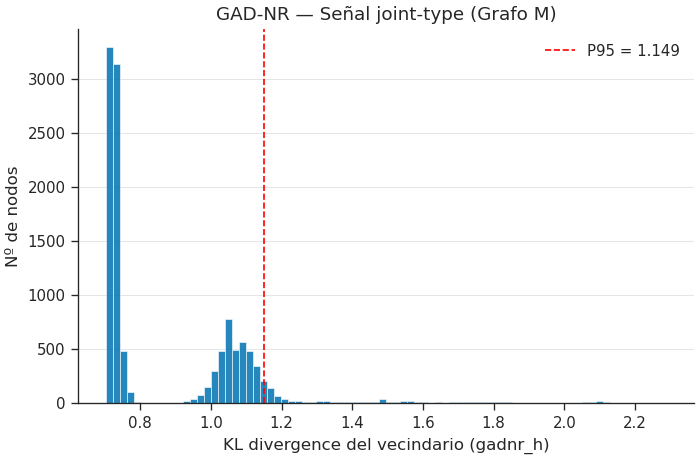

In [25]:
# Distribución del score joint-type
fig, ax = plt.subplots(figsize=FS['single'])

ax.hist(scores_df['gadnr_h'], bins=80,
        color=PALETTE['M'], edgecolor='white', alpha=0.85)
p95_h = np.percentile(scores_df['gadnr_h'], 95)
ax.axvline(p95_h, color="red", linestyle='--', linewidth=1.0,
           label=f'P95 = {p95_h:.3f}')

ax.set_xlabel('KL divergence del vecindario (gadnr_h)', fontsize=FONT['axis_label'])
ax.set_ylabel('Nº de nodos', fontsize=FONT['axis_label'])
ax.set_title('GAD-NR — Señal joint-type (Grafo M)', fontsize=FONT['title'])
ax.legend(fontsize=FONT['legend'], frameon=False)
polish(ax)
plt.tight_layout()
save_figure(fig, '05_gadnr_joint_type_M.png')
plt.show()


## 6. Spotlight — candidatos del EDA

Revisamos los candidatos identificados en el EDA con las cinco señales
disponibles. Para cada candidato mostramos el percentil en cada señal
y si supera el umbral P95.


In [26]:
def spotlight(name_fragment, df, label=None):
    matches = df[df['name'].str.contains(name_fragment, case=False, na=False)]
    if len(matches) == 0:
        print(f'  [no encontrado] {name_fragment}')
        return
    row = matches.iloc[0]
    n   = len(df)
    def rank(col): return int((df[col] > row[col]).sum()) + 1
    def flag(pct): return '⚠' if pct >= P_THRESH else ' '

    tag = label or str(row['name'])
    print(f'  ► {tag}')
    print(f'    Ciudad: {row["city"]} ({row["state"]}) | Grado: {row["degree"]}')
    print(f'    DOMINANT  estructural : #{rank("dom_struct"):5d}/{n}  '
          f'({row["pct_dom_struct"]:.1f}p) {flag(row["pct_dom_struct"])}')
    print(f'    DOMINANT  atributo    : #{rank("dom_attr"):5d}/{n}  '
          f'({row["pct_dom_attr"]:.1f}p) {flag(row["pct_dom_attr"])}')
    print(f'    GAD-NR    estructural : #{rank("gadnr_deg"):5d}/{n}  '
          f'({row["pct_gadnr_deg"]:.1f}p) {flag(row["pct_gadnr_deg"])}')
    print(f'    GAD-NR    atributo    : #{rank("gadnr_feat"):5d}/{n}  '
          f'({row["pct_gadnr_feat"]:.1f}p) {flag(row["pct_gadnr_feat"])}')
    print(f'    GAD-NR    joint-type  : #{rank("gadnr_h"):5d}/{n}  '
          f'({row["pct_gadnr_h"]:.1f}p) {flag(row["pct_gadnr_h"])}')
    print()

print('=' * 70)
print('CANDIDATOS DEL EDA — LAS 5 SEÑALES')
print('=' * 70 + '')

candidatos = [
    ('Pablo',         'Pablo (alta betweenness, degree moderada)'),
    ('Shalini',       'Shalini (mayor betweenness de la red)'),
    ('Jim H',         'Jim H (super-conector + puente inter-comunidad)'),
    ('Matt Kenigson', 'Matt Kenigson (super-conector)'),
    ('GEEK',          'GEEK by AKEIN Engineering (entidad no personal)'),
]

for frag, label in candidatos:
    spotlight(frag, scores_df, label=label)


CANDIDATOS DEL EDA — LAS 5 SEÑALES
  ► Pablo (alta betweenness, degree moderada)
    Ciudad: Nashville (TN) | Grado: 688
    DOMINANT  estructural : #   16/11371  (99.9p) ⚠
    DOMINANT  atributo    : # 5156/11371  (54.7p)  
    GAD-NR    estructural : #10139/11371  (10.8p)  
    GAD-NR    atributo    : #11294/11371  (0.7p)  
    GAD-NR    joint-type  : # 7843/11371  (31.0p)  

  ► Shalini (mayor betweenness de la red)
    Ciudad: Nashville (TN) | Grado: 955
    DOMINANT  estructural : #    2/11371  (100.0p) ⚠
    DOMINANT  atributo    : # 5848/11371  (48.6p)  
    GAD-NR    estructural : #    9/11371  (99.9p) ⚠
    GAD-NR    atributo    : #11264/11371  (0.9p)  
    GAD-NR    joint-type  : # 8264/11371  (27.3p)  

  ► Jim H (super-conector + puente inter-comunidad)
    Ciudad: Nashville (TN) | Grado: 1178
    DOMINANT  estructural : #    1/11371  (100.0p) ⚠
    DOMINANT  atributo    : # 4753/11371  (58.2p)  
    GAD-NR    estructural : #    1/11371  (100.0p) ⚠
    GAD-NR    atributo   

In [27]:
# Tabla resumen ejecutivo
rows = []
for frag, label in candidatos:
    matches = scores_df[scores_df['name'].str.contains(frag, case=False, na=False)]
    if len(matches) == 0:
        continue
    row = matches.iloc[0]
    n   = len(scores_df)
    def rank(col): return int((scores_df[col] > row[col]).sum()) + 1
    def flag(pct): return '⚠' if pct >= P_THRESH else ''

    rows.append({
        'Candidato':      label.split('(')[0].strip(),
        'DOM-struct':     f'#{rank("dom_struct")} ({row["pct_dom_struct"]:.0f}p){flag(row["pct_dom_struct"])}',
        'DOM-attr':       f'#{rank("dom_attr")} ({row["pct_dom_attr"]:.0f}p){flag(row["pct_dom_attr"])}',
        'GADNR-struct':   f'#{rank("gadnr_deg")} ({row["pct_gadnr_deg"]:.0f}p){flag(row["pct_gadnr_deg"])}',
        'GADNR-attr':     f'#{rank("gadnr_feat")} ({row["pct_gadnr_feat"]:.0f}p){flag(row["pct_gadnr_feat"])}',
        'GADNR-joint':    f'#{rank("gadnr_h")} ({row["pct_gadnr_h"]:.0f}p){flag(row["pct_gadnr_h"])}',
    })

print('=== Resumen ejecutivo — candidatos del EDA ===')
print(pd.DataFrame(rows).to_string(index=False))


=== Resumen ejecutivo — candidatos del EDA ===
                Candidato  DOM-struct    DOM-attr GADNR-struct  GADNR-attr GADNR-joint
                    Pablo #16 (100p)⚠ #5156 (55p) #10139 (11p) #11294 (1p) #7843 (31p)
                  Shalini  #2 (100p)⚠ #5848 (49p)   #9 (100p)⚠ #11264 (1p) #8264 (27p)
                    Jim H  #1 (100p)⚠ #4753 (58p)   #1 (100p)⚠ #11276 (1p) #8860 (22p)
            Matt Kenigson  #3 (100p)⚠ #5745 (49p)   #78 (99p)⚠ #11228 (1p) #6591 (42p)
GEEK by AKEIN Engineering #11367 (0p) #3641 (68p)  #11211 (1p) #5347 (53p) #2805 (75p)


## 7. Comparativa general

Heatmap de correlación Spearman entre las cinco señales y análisis del
acuerdo entre modelos a nivel de etiqueta binaria (P95).


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_signal_correlation_M.png


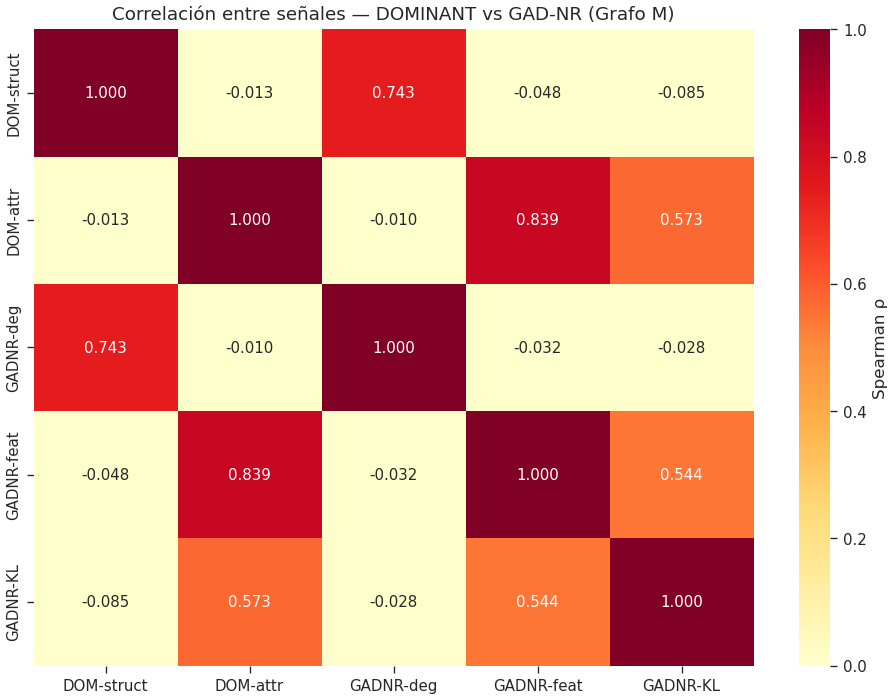

In [28]:
# Heatmap de correlación entre las 5 señales
score_cols   = ['dom_struct', 'dom_attr', 'gadnr_deg', 'gadnr_feat', 'gadnr_h']
score_labels = ['DOM-struct', 'DOM-attr', 'GADNR-deg', 'GADNR-feat', 'GADNR-KL']

n_s = len(score_cols)
corr_matrix = np.zeros((n_s, n_s))
for i, c1 in enumerate(score_cols):
    for j, c2 in enumerate(score_cols):
        rho, _ = spearmanr(scores_df[c1], scores_df[c2])
        corr_matrix[i, j] = rho

fig, ax = plt.subplots(figsize=FS['heatmap'])
sns.heatmap(
    corr_matrix, annot=True, fmt='.3f', cmap=CMAP_HEAT,
    vmin=0, vmax=1, ax=ax,
    xticklabels=score_labels, yticklabels=score_labels,
    cbar_kws={'label': 'Spearman ρ'}
)
ax.set_title('Correlación entre señales — DOMINANT vs GAD-NR (Grafo M)',
             fontsize=FONT['title'])
plt.tight_layout()
save_figure(fig, '05_signal_correlation_M.png')
plt.show()


In [29]:
# Acuerdo entre tipologías: ¿asignan el mismo tipo los dos modelos?
print('=== Acuerdo entre tipologías DOMINANT vs GAD-NR ===')
print(pd.crosstab(
    scores_df['type_dom'],
    scores_df['type_gadnr'],
    rownames=['DOMINANT'],
    colnames=['GAD-NR']
))


=== Acuerdo entre tipologías DOMINANT vs GAD-NR ===
GAD-NR       Atributo  Estructural  Mixta  Normal
DOMINANT                                         
Atributo          315            2      5     231
Estructural        15          344     11     183
Mixta               1            4     10       1
Normal            208          188      5    9848


## 8. Visualización t-SNE de los embeddings

Para cerrar el análisis, proyectamos los **embeddings latentes** de cada modelo a 2D
mediante **t-SNE** (van der Maaten & Hinton, 2008). t-SNE preserva las relaciones
locales — nodos vecinos en el espacio latente quedan próximos en 2D — y es la
herramienta estándar para inspeccionar visualmente la estructura aprendida por una red.

Para cada modelo generamos tres vistas:

1. **Coloreado por tipo de anomalía** — verifica si los nodos asignados a una misma
   tipología se agrupan en el espacio latente del modelo. Una buena separación valida
   que el detector ha aprendido representaciones coherentes con su tipología.

2. **Coloreado por score compuesto** — gradiente continuo que muestra si la intensidad
   de anomalía sigue una estructura espacial (regiones del espacio latente con scores
   sistemáticamente altos).

3. **Coloreado por grado del nodo** — comprobación final: ¿el modelo está separando
   nodos por grado o ha aprendido representaciones más ricas? Una correlación
   perfecta entre grado y posición indicaría que el embedding es esencialmente una
   función del grado, lo cual es señal de poco aprendizaje.

**Coste computacional.** t-SNE con 11.371 puntos tarda 2-4 minutos por modelo en CPU.
Inicializamos con PCA (`init='pca'`) — más estable que `random` para muchos puntos —
y fijamos `random_state=SEED` para reproducibilidad.


In [30]:
# Extracción de embeddings finales de ambos modelos
@torch.no_grad()
def get_dominant_embeddings(detector, data):
    """
    El encoder GCN compartido de DOMINANT es la primera mitad del modelo.
    Llamamos a model.shared_encoder(x, edge_index) para obtener Z.
    """
    model = detector.model
    model.eval()
    x          = data.x.to(detector.device)
    edge_index = data.edge_index.to(detector.device)
    z = model.shared_encoder(x, edge_index)
    return z.cpu().numpy()


@torch.no_grad()
def get_gadnr_embeddings(detector, data):
    """
    GAD-NR: el encoder produce h0 (representación pre-decoder). Es el
    output de la GCN antes del MLP de reducción de vecindario.
    """
    model = detector.model
    model.eval()
    data.x          = data.x.to(detector.device)
    data.edge_index = data.edge_index.to(detector.device)
    h0, _, _, _ = model(data.x, data.edge_index)
    return h0.cpu().numpy()


emb_dom   = get_dominant_embeddings(dominant, data_M_clean)
emb_gadnr = get_gadnr_embeddings(gadnr,      data_M_clean)

print(f'Embeddings DOMINANT : {emb_dom.shape}')
print(f'Embeddings GAD-NR   : {emb_gadnr.shape}')


Embeddings DOMINANT : (11371, 64)
Embeddings GAD-NR   : (11371, 64)


In [31]:
from sklearn.manifold import TSNE

def run_tsne(embeddings, label):
    print(f'Calculando t-SNE sobre embeddings de {label}...')
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        max_iter=1000,
        init='pca',
        learning_rate='auto',
        random_state=SEED,
        verbose=0,
    )
    return tsne.fit_transform(embeddings)


tsne_dom   = run_tsne(emb_dom,   'DOMINANT')
tsne_gadnr = run_tsne(emb_gadnr, 'GAD-NR')

print(f't-SNE DOMINANT shape: {tsne_dom.shape}')
print(f't-SNE GAD-NR  shape: {tsne_gadnr.shape}')


Calculando t-SNE sobre embeddings de DOMINANT...
Calculando t-SNE sobre embeddings de GAD-NR...
t-SNE DOMINANT shape: (11371, 2)
t-SNE GAD-NR  shape: (11371, 2)


[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_dominant_tsne_type_M.png


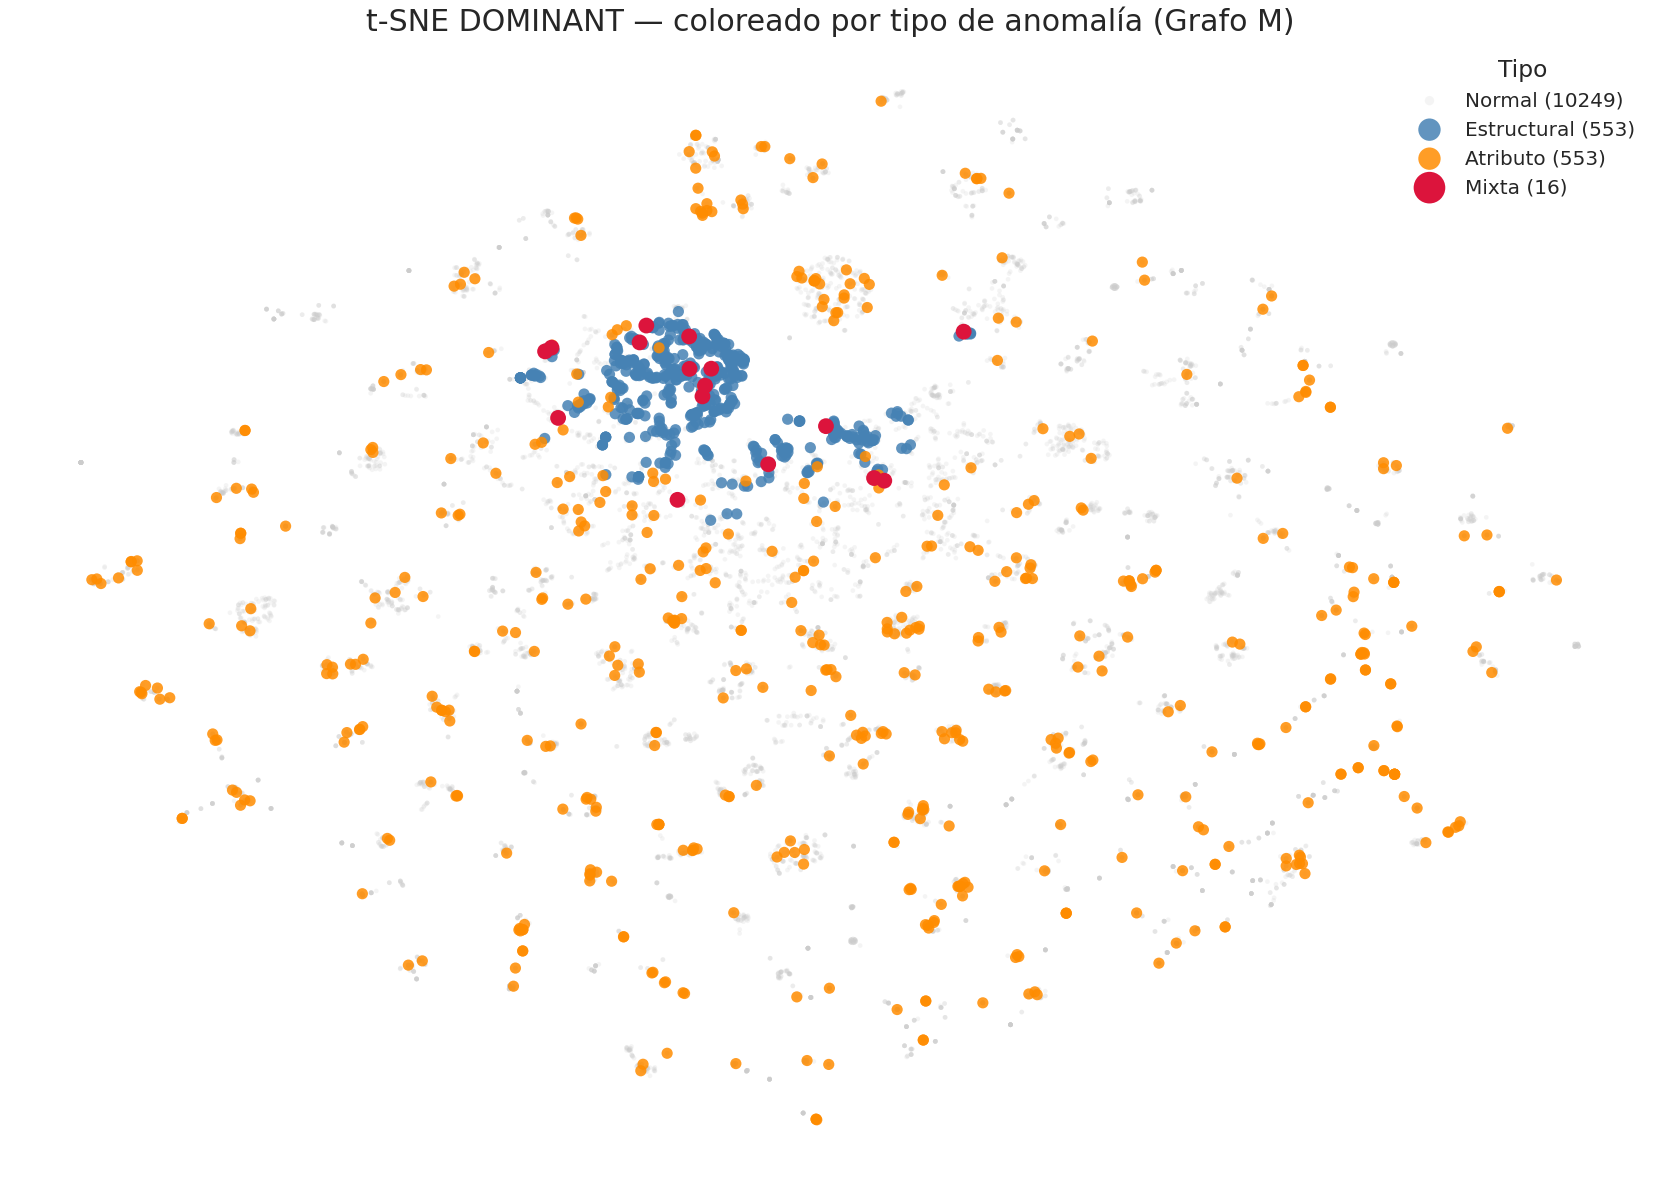

[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_dominant_tsne_score_M.png


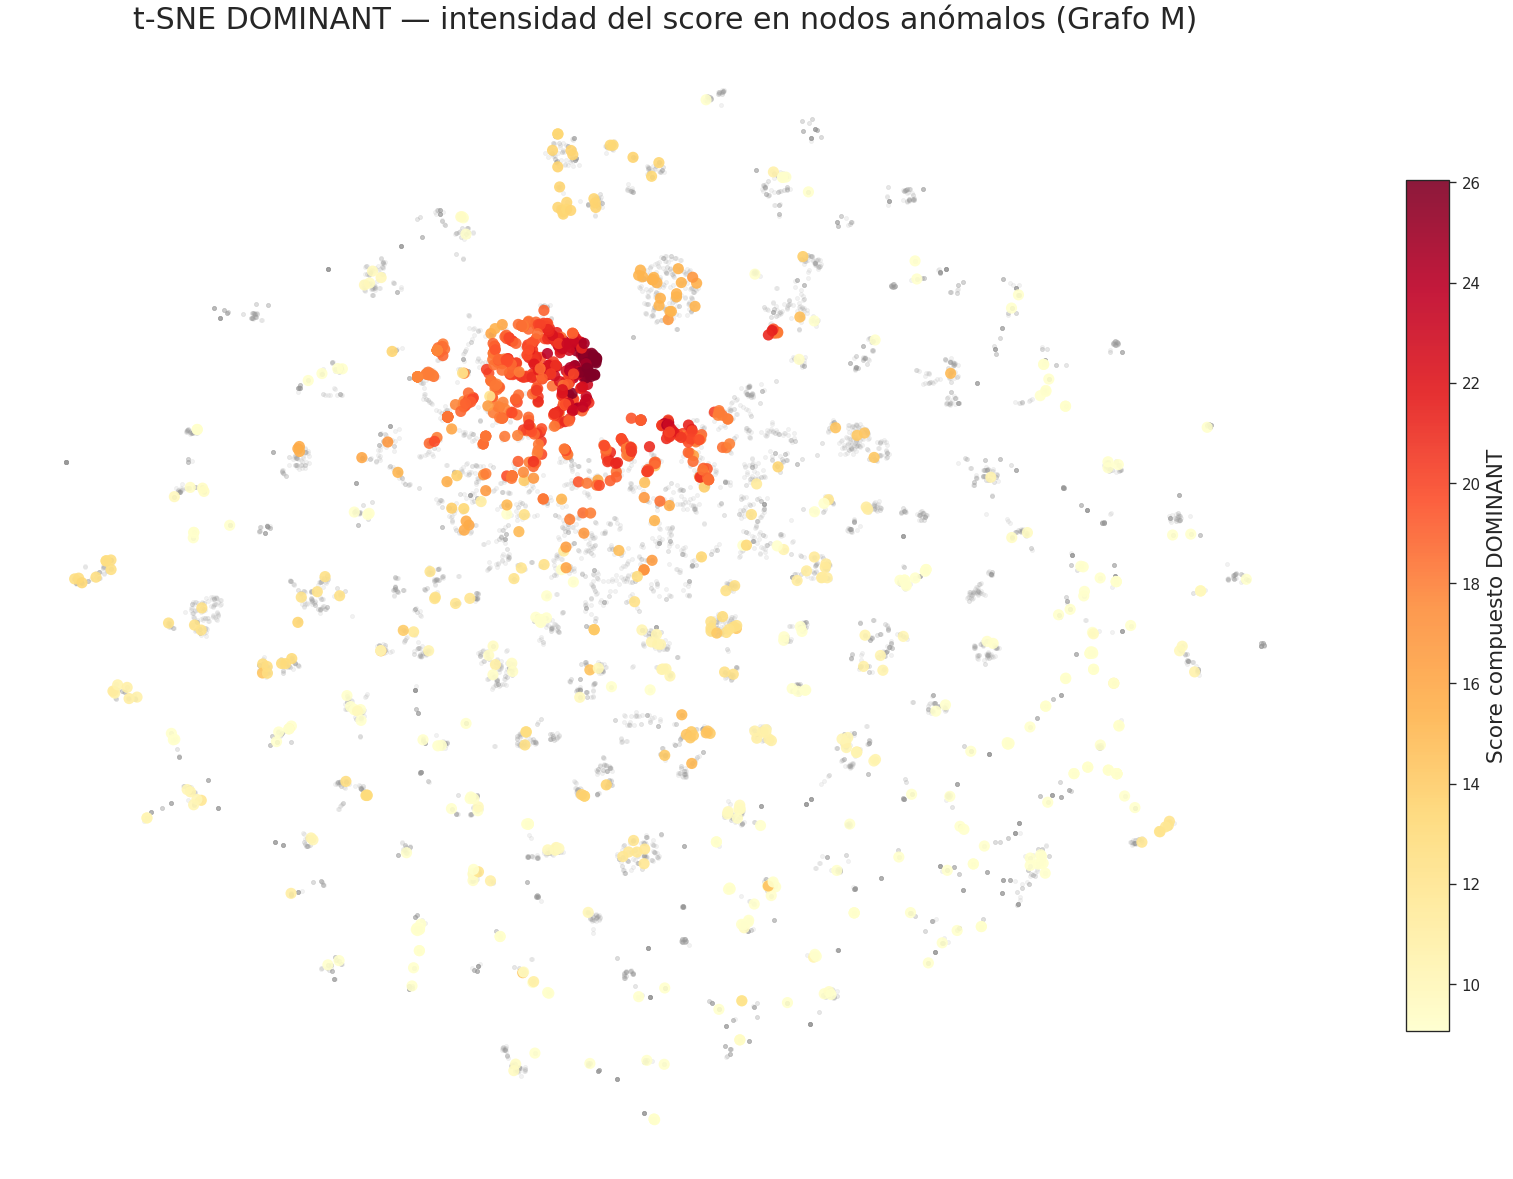

[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_dominant_tsne_degree_M.png


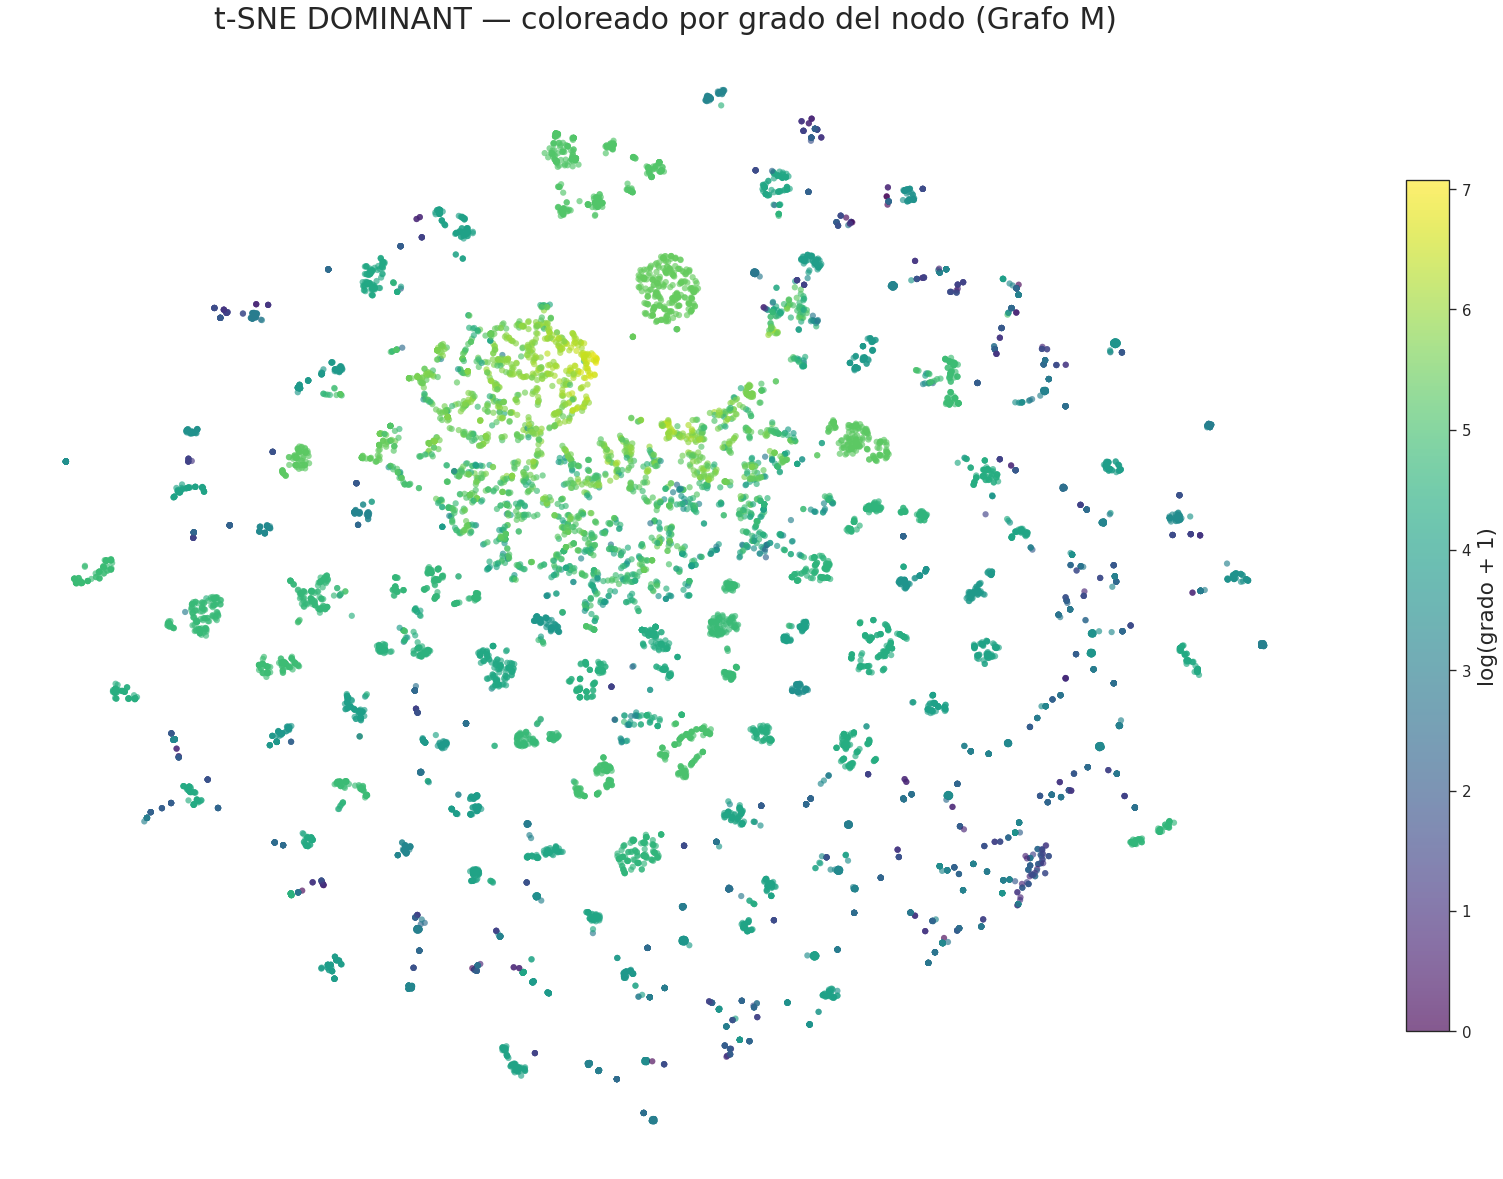

[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_gadnr_tsne_type_M.png


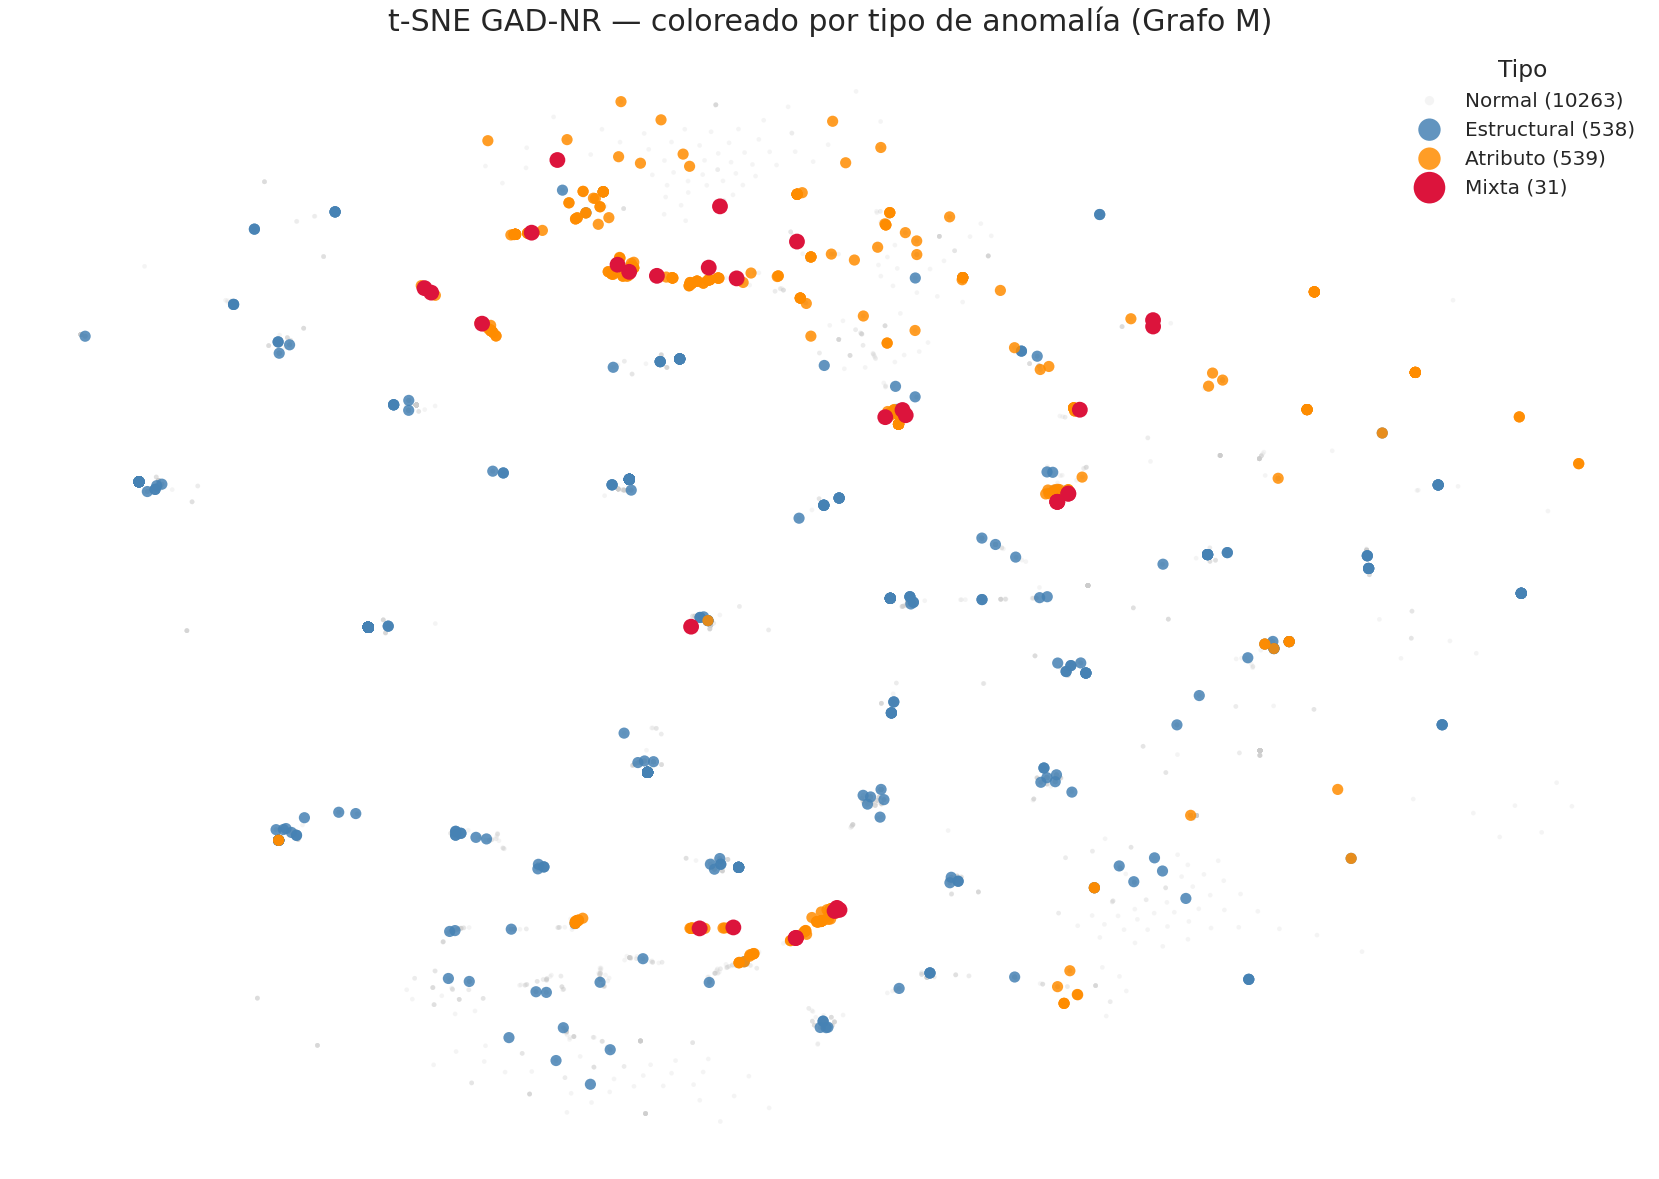

[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_gadnr_tsne_score_M.png


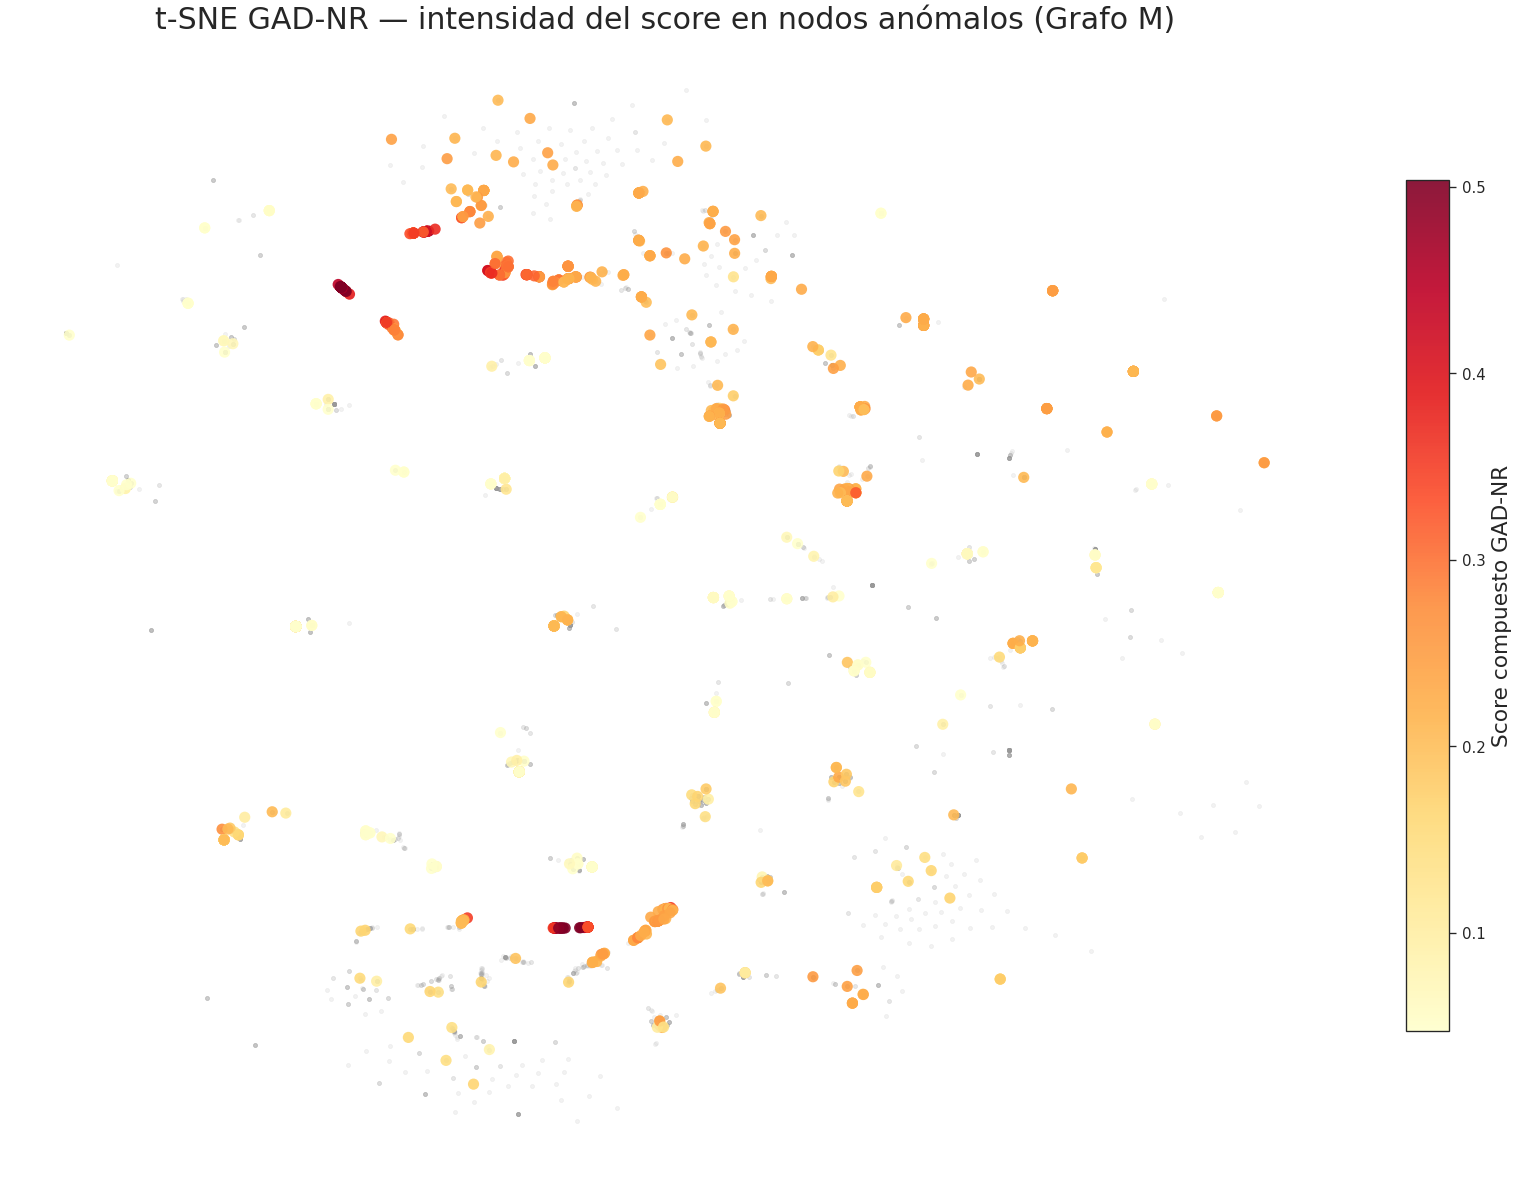

[viz] saved -> C:\Personal\MCD\TFM\results\figures\05_gadnr_tsne_degree_M.png


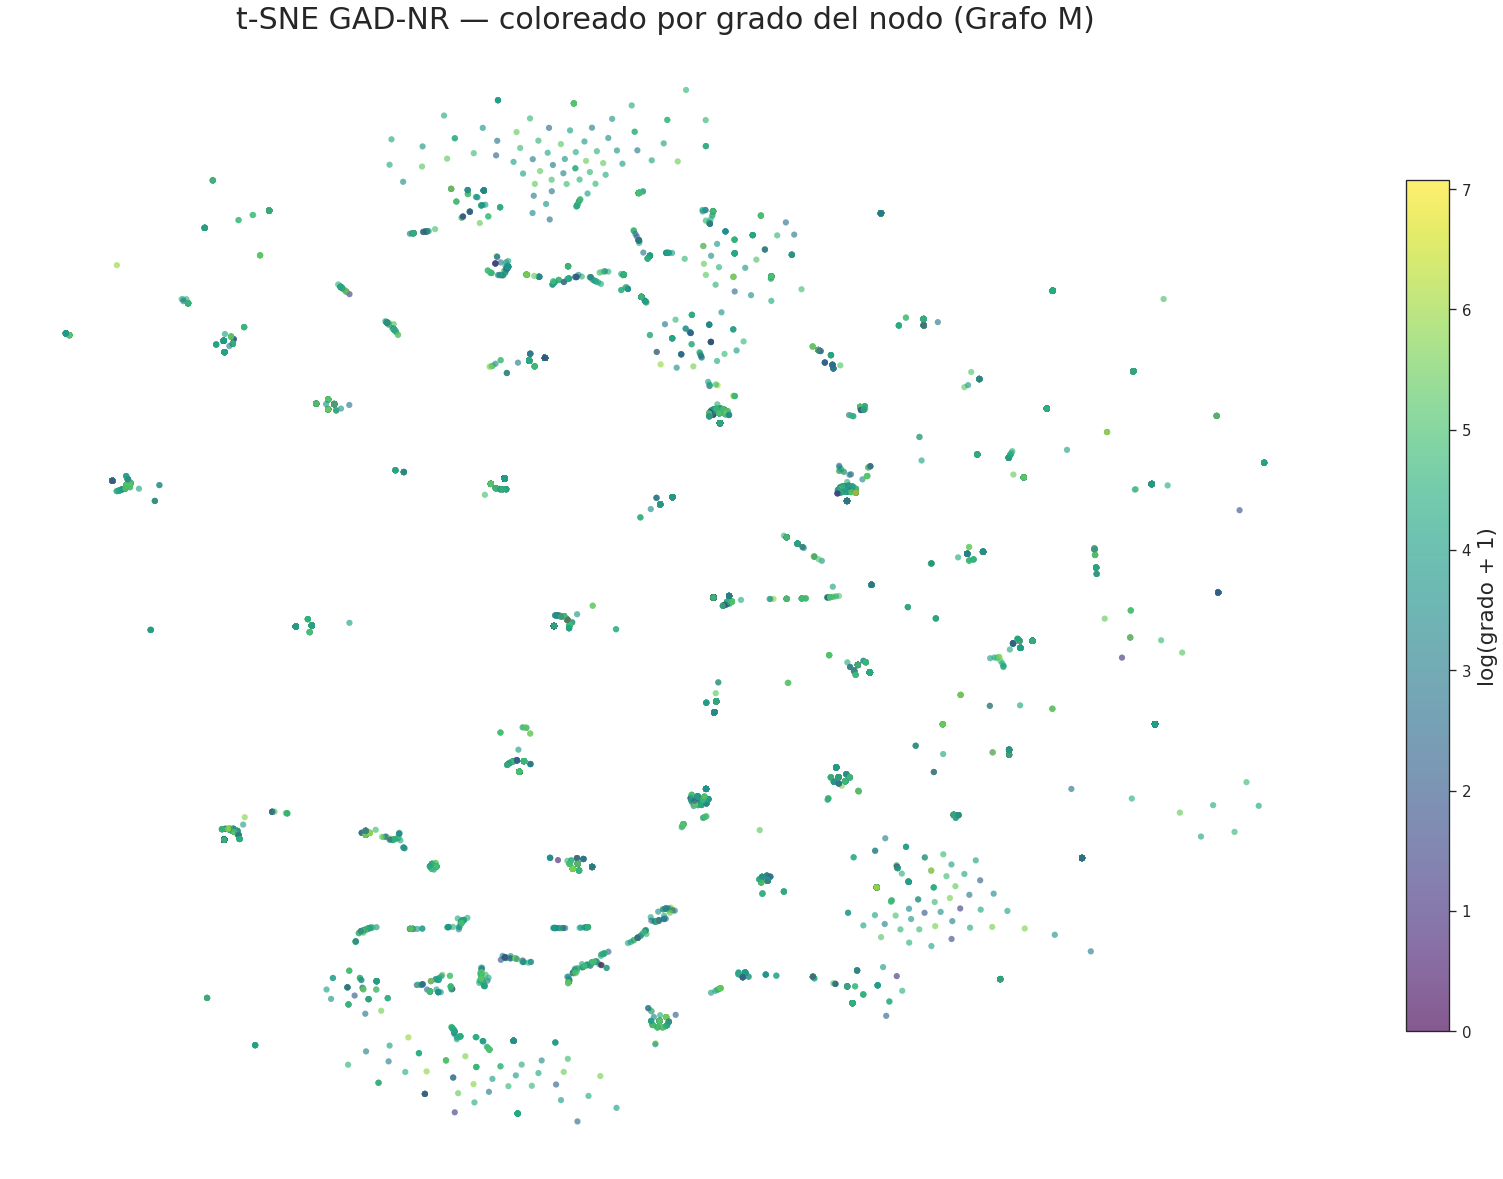

In [32]:
def plot_tsne_panel(tsne_coords, scores_df, model_name, type_col, score_col,
                    figname_prefix):
    """Genera las tres vistas t-SNE para un modelo: tipo, score, grado."""
    # Fuentes escaladas para figuras (14, 10)
    FONT_TSNE = {
        'title':      18,
        'axis_label': 13,
        'legend':     12,
        'annotation': 10,
    }

    def remove_all_spines(ax):
        for spine in ax.spines.values():
            spine.set_visible(False)

    # ── Vista 1: tipo de anomalía ────────────────────────────────────────
    style_by_type = {
        'Normal':      (color_map['Normal'],      0.20,  8),
        'Estructural': (color_map['Estructural'], 0.85, 45),
        'Atributo':    (color_map['Atributo'],    0.85, 45),
        'Mixta':       (color_map['Mixta'],       1.00, 90),
    }

    fig, ax = plt.subplots(figsize=(14, 10))
    for atype in ['Normal', 'Estructural', 'Atributo', 'Mixta']:
        mask = scores_df[type_col] == atype
        color, alpha, size = style_by_type[atype]
        zorder = 1 if atype == 'Normal' else 3
        ax.scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
                   s=size, alpha=alpha, color=color,
                   label=f'{atype} ({mask.sum()})',
                   zorder=zorder, edgecolors='none')

    ax.set_title(f't-SNE {model_name} — coloreado por tipo de anomalía (Grafo M)',
                 fontsize=FONT_TSNE['title'])
    ax.legend(title='Tipo', fontsize=FONT_TSNE['legend'], frameon=False, title_fontsize=FONT_TSNE['legend'] + 2,
              markerscale=2.0, loc='upper right')
    ax.set_xticks([]); ax.set_yticks([])
    remove_all_spines(ax)
    plt.tight_layout()
    save_figure(fig, f'{figname_prefix}_tsne_type_M.png')
    plt.show()

    # ── Vista 2: score compuesto (gradiente continuo) ────────────────────
    anom_mask = scores_df[type_col] != 'Normal'
    normal_mask = ~anom_mask
    vmin_val = scores_df.loc[anom_mask, score_col].quantile(0.20)
    vmax_val = scores_df.loc[anom_mask, score_col].quantile(0.98)

    fig, ax = plt.subplots(figsize=(14, 10))
    ax.scatter(tsne_coords[normal_mask, 0], tsne_coords[normal_mask, 1],
               s=6, alpha=0.12, color=PALETTE['neutral'], zorder=1)

    sc = ax.scatter(
        tsne_coords[anom_mask, 0], tsne_coords[anom_mask, 1],
        c=scores_df.loc[anom_mask, score_col],
        s=45, alpha=0.90, cmap=CMAP_HEAT, zorder=3,
        vmin=vmin_val,
        vmax=vmax_val,
        edgecolors='none',
    )
    cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
    cbar.set_label(f'Score compuesto {model_name}', fontsize=FONT_TSNE['axis_label'])
    ax.set_title(f't-SNE {model_name} — intensidad del score en nodos anómalos (Grafo M)',
                 fontsize=FONT_TSNE['title'])
    ax.set_xticks([]); ax.set_yticks([])
    remove_all_spines(ax)
    plt.tight_layout()
    save_figure(fig, f'{figname_prefix}_tsne_score_M.png')
    plt.show()

    # ── Vista 3: grado del nodo (escala log) ─────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 10))
    sc = ax.scatter(
        tsne_coords[:, 0], tsne_coords[:, 1],
        c=np.log1p(scores_df['degree']),
        s=14, alpha=0.65, cmap=CMAP_SEQ, edgecolors='none',
    )
    cbar = plt.colorbar(sc, ax=ax, shrink=0.75)
    cbar.set_label('log(grado + 1)', fontsize=FONT_TSNE['axis_label'])
    ax.set_title(f't-SNE {model_name} — coloreado por grado del nodo (Grafo M)',
                 fontsize=FONT_TSNE['title'])
    ax.set_xticks([]); ax.set_yticks([])
    remove_all_spines(ax)
    plt.tight_layout()
    save_figure(fig, f'{figname_prefix}_tsne_degree_M.png')
    plt.show()


# t-SNE DOMINANT
plot_tsne_panel(
    tsne_coords=tsne_dom,
    scores_df=scores_df,
    model_name='DOMINANT',
    type_col='type_dom',
    score_col='dom_combined',
    figname_prefix='05_dominant',
)

# t-SNE GAD-NR
plot_tsne_panel(
    tsne_coords=tsne_gadnr,
    scores_df=scores_df,
    model_name='GAD-NR',
    type_col='type_gadnr',
    score_col='gadnr_score',
    figname_prefix='05_gadnr',
)

## 9. Guardado de resultados


In [33]:
cols_export = [
    'idx', 'member_id', 'name', 'city', 'state', 'degree',
    # Sub-scores brutos
    'dom_struct', 'dom_attr', 'dom_combined',
    'gadnr_h', 'gadnr_deg', 'gadnr_feat', 'gadnr_score',
    # Percentiles
    'pct_dom_struct', 'pct_dom_attr',
    'pct_gadnr_deg', 'pct_gadnr_feat', 'pct_gadnr_h',
    # Tipologías
    'type_dom', 'type_gadnr',
]

scores_export = scores_df[[c for c in cols_export if c in scores_df.columns]]
scores_export.to_csv(os.path.join(RESULTS_PATH, 'scores_M.csv'), index=False)

print(f'Guardado : {RESULTS_PATH}scores_M.csv')
print(f'Shape    : {scores_export.shape}')

# Embeddings finales y coordenadas t-SNE
np.savez(
    os.path.join(RESULTS_PATH, 'embeddings_M.npz'),
    emb_dom=emb_dom,
    emb_gadnr=emb_gadnr,
    tsne_dom=tsne_dom,
    tsne_gadnr=tsne_gadnr,
    member_ids=np.array(member_ids),
)
print(f'Guardado : {RESULTS_PATH}embeddings_M.npz')


Guardado : ../data/results/scores_M.csv
Shape    : (11371, 20)
Guardado : ../data/results/embeddings_M.npz


## Resumen del notebook

En este notebook hemos:

1. **Entrenado DOMINANT** (300 épocas, loss convergente) y extraído `dom_struct`
   (estructural, RMSE de adyacencia) y `dom_attr` (atributo, RMSE de features).
   La correlación Spearman entre ambas señales es ρ = −0.004 — prácticamente
   ortogonales, confirmando que capturan tipos de anomalía independientes.

2. **Entrenado GAD-NR** (300 épocas) con lambdas iniciales ajustados a la escala
   de cada loss en el grafo M. Extraído `gadnr_h` (vecindario / joint-type, rango
   0.94–3.55), `gadnr_deg` (estructural, rango 0.04–1.064.000) y `gadnr_feat`
   (atributo, rango 0.04–0.24). Los sub-scores de GAD-NR son prácticamente
   ortogonales entre sí (ρ máximo = 0.077).

3. **Documentado en la sección 4.1** el comportamiento del mecanismo interno de
   re-ponderación de lambdas de GAD-NR: los lambdas declarados (0.01 / 0.1 / 0.8)
   derivan en lambdas finales (0.01 / 7.6 / 2.4·10⁻⁵) que hacen que el score
   compuesto esté dominado casi en exclusiva por la señal de features. Esta
   observación justifica el enfoque metodológico basado en sub-scores individuales.

4. **Comparado las señales equivalentes** estructural vs estructural (ρ = 0.668,
   solapamiento top-100 = 39%) y atributo vs atributo (ρ = 0.447, solapamiento = 2%).
   La señal estructural es la más coherente entre modelos; la de atributo diverge
   casi completamente como consecuencia directa del curriculum.

5. **Comparado los scores compuestos**: correlación Spearman ρ = 0.575, solapamiento
   top-100 = 35%. La escala de los scores es incomparable entre modelos (DOMINANT:
   media 9.63, GAD-NR: media 1.09), lo que confirma que solo el ranking es comparable.

6. **Analizado la señal joint-type** de GAD-NR de forma independiente: identifica
   496 nodos invisibles para DOMINANT, con grado medio 65.5 (vs 103.2 global).
   Los top-10 son mayoritariamente nodos con grado 0–4, lo que sugiere que la señal
   KL en este grafo captura en parte nodos con vecindarios muy pequeños donde la
   reconstrucción de la distribución de vecinos es intrínsecamente más difícil.

7. **Validado los candidatos del EDA** con las cinco señales:
   - Shalini y Jim H: anomalía estructural confirmada por ambos modelos (P100 en ambos).
   - Matt Kenigson: estructural en ambos (P100 DOM / P98.9 GADNR).
   - Pablo: anomalía estructural solo en DOMINANT (P99.9) — GAD-NR no lo detecta (P1.1).
   - GEEK by AKEIN Engineering: ninguna señal estructural ni de atributo lo detecta
     (grado 0, sin vecindario), aunque la señal KL es moderadamente alta (P87.6).

8. **Visualizado los embeddings latentes** con t-SNE en tres vistas por modelo.
   DOMINANT agrupa los nodos estructurales en un cluster compacto bien separado,
   con gradiente de score coherente. GAD-NR muestra estructura dispersa sin clustering
   claro por tipología, consistente con el dominio de la señal de features geográficas
   de baja varianza en su embedding.

Los resultados quedan en `scores_M.csv` (11.371 nodos × 20 columnas) y `embeddings_M.npz`.
